# 03 — Hierarchical inference with selection effects

In notebooks 01 and 02 we generated a controlled mock data set:

- notebook 01 generated an intrinsic binary-neutron-star population;
- notebook 02 selected detectable events and generated mock single-event PE samples.

In this notebook we perform the first hierarchical inference.

The goal is to infer population-level and EOS-level parameters from the mock PE samples, while correcting for selection effects.

The key idea is that all events are drawn from a common population model and share the same EOS relation.

Schematically, for event-level parameters $\theta_i$ and hyperparameters $\lambda$,

$$
p(\lambda|\{d_i\})
\propto
\pi(\lambda)
\prod_i p(d_i|\lambda)
\times
\text{selection correction}.
$$

Here $\lambda$ includes both population parameters and EOS parameters.

In this notebook the hyperparameters include:

- parameters of the source-frame mass distribution;
- parameters of the redshift distribution;
- polynomial coefficients describing the EOS relation $\Lambda_{\rm EOS}(m)$.

The inference uses two Monte Carlo ingredients produced in notebook 02:

1. PE posterior samples for each detected event;
2. detected injections for estimating the selection correction.

The central object of the notebook is the rate-marginalized hierarchical likelihood,

$$
\log \mathcal{L}(\lambda)
=
\sum_{i=1}^{N_{\rm det}}
\log p(d_i|\lambda)
-
N_{\rm det}\log \xi(\lambda),
$$

where $\xi(\lambda)$ is the selection efficiency, also called the detectable fraction.

This likelihood is implemented in NumPyro and sampled using NUTS.

## Colab setup

If running on Colab, first clone the repository and enter it. If running locally from the repository root, skip this cell.


In [ ]:
# # Run this cell only on Colab.
# from google.colab import drive
# drive.mount('/content/drive')

# %cd /content/drive/MyDrive
# %cd ns-eos-population-tutorial

# !pip install -q numpyro corner


## Imports and paths


In [ ]:
from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt

import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import jax.scipy as jsp

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, init_to_value

import arviz as az
import corner

from astropy.cosmology import Planck18 as cosmology
from astropy.constants import c

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

processed_dir = project_root / "data/processed"
figures_dir = project_root / "figures"
results_dir = project_root / "results"

figures_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

C_KM_S = c.to("km/s").value


## Runtime choices

The runtime choices control how expensive the demonstration is.

The full simulated data set may contain many detected events, many PE samples per event, and many detected injections. For a classroom tutorial it is useful to start with smaller numbers:

- `n_events_use`: how many detected events enter the hierarchical likelihood;
- `n_pe_use`: how many PE samples are used per event;
- `n_injections_use`: how many detected injections are used for the selection correction.

Reducing these numbers makes the notebook faster, but increases Monte Carlo noise.

The switches

```python
apply_hard_eos_physical_prior
apply_hard_mc_variance_cut
```

control whether we only **diagnose** problematic regions of parameter space, or whether we also **exclude** them during sampling.

### EOS physical prior

The sampled EOS coefficients define a curve

$$
\Lambda_{\rm EOS}(m;\phi_{\rm EOS}).
$$

Not every polynomial coefficient vector gives a physically sensible or numerically usable EOS curve. Some proposed curves can become negative, diverge, increase with mass, or leave the mass range where the polynomial surrogate is meaningful.

The code checks the proposed EOS curve on a fixed mass grid. The proposal is considered physically acceptable only if

$$
\Lambda_{\rm EOS}(m) > 0
$$

for all grid points,

$$
\Lambda_{\rm EOS}(m) < \Lambda_{\rm max}
$$

for all grid points,

$$
\Lambda_{\rm EOS}(m)
$$

is finite for all grid points, and the curve is monotonically decreasing,

$$
\frac{d\Lambda_{\rm EOS}}{dm} < 0.
$$

In the code this is checked discretely on the mass grid as

$$
\Lambda_{\rm EOS}(m_{j+1}) < \Lambda_{\rm EOS}(m_j).
$$

If

```python
apply_hard_eos_physical_prior = False
```

then these checks are only stored as diagnostics. The sampler is allowed to visit these regions, and we can later inspect how often unphysical EOS curves were proposed.

If

```python
apply_hard_eos_physical_prior = True
```

then parameter values that fail these checks are rejected by assigning them negligible posterior probability.

This is a hard prior on the **function** $\Lambda_{\rm EOS}(m)$, not just on the polynomial coefficients. It is useful because simple coefficient priors do not automatically imply physical EOS curves.

### Monte Carlo variance cut

The hierarchical likelihood is estimated using finite Monte Carlo sums:

- a sum over PE samples for each event;
- a sum over detected injections for the selection correction.

Therefore the likelihood estimate itself has Monte Carlo noise.

The code estimates the variance of the log-likelihood estimator,

$$
\sigma^2_{\log \widehat{\mathcal{L}}}.
$$

The usual population-inference requirement is that this variance should be small, typically

$$
\sigma^2_{\log \widehat{\mathcal{L}}} < 1.
$$

If

```python
apply_hard_mc_variance_cut = False
```

then this quantity is only recorded as a diagnostic. This is useful for teaching, because we can see where the likelihood becomes noisy.

If

```python
apply_hard_mc_variance_cut = True
```

then proposals with

$$
\sigma^2_{\log \widehat{\mathcal{L}}} > 1
$$

are rejected.

This cut does not represent physics. It is a numerical reliability condition: it prevents the sampler from trusting hyperparameter values for which the PE samples or injections provide a noisy Monte Carlo estimate of the likelihood.

In [ ]:
# These control runtime only. They do not change the generated catalog.
n_events_use = 20
n_pe_use = 500
n_injections_use = 2_000

# NumPyro settings.
num_warmup = 200
num_samples = 200
num_chains = 2
rng_seed = 123

# Optional hard cuts. Use these to test with/without the constraints.
apply_hard_eos_physical_prior = False
apply_hard_mc_variance_cut = False

# GWTC-style Monte Carlo likelihood variance cut.
max_log_likelihood_variance = 1.0


## Load data from previous notebooks

This notebook loads four kinds of objects.

### EOS fit

The EOS fit from notebook 00 provides the polynomial surrogate

$$
\log \Lambda_{\rm EOS}(m)
=
a_0 m^K + a_1 m^{K-1}+\cdots+a_K.
$$

The coefficients $a_k$ are the EOS parameters that we will infer in this notebook.

### Intrinsic population

The intrinsic population from notebook 01 contains the simulation truth. It is mainly used here to retrieve the true parameter values and settings used to generate the mock data.

### Mock detected events and PE samples

Notebook 02 produced a detected catalog and mock PE samples for each detected event.

The PE samples are in detector-frame variables,

$$
m_{1,z},\quad m_{2,z},\quad d_L.
$$

The mock tidal measurement is stored separately as

$$
\hat{\ell}_i = \widehat{\log\tilde{\Lambda}}_i,
\qquad
\sigma_{\ell,i}.
$$

This is because the mock likelihood for the tidal parameter is Gaussian in $\log\tilde{\Lambda}$.

### Detected injections

The detected injections are used to estimate the selection correction,

$$
\xi(\lambda)
=
\int p_{\rm det}(\theta)\,p_{\rm pop}(\theta|\lambda)\,d\theta.
$$

For each detected injection we need its parameters and the probability density with which it was drawn.

In [ ]:
# Tagged inputs from notebooks 00--02.
# Edit these filenames if you changed the upstream tags.
eos_fit_filename = "eos_fit__bsk24_m1p00_2p25_poly5.npz"
population_filename = "intrinsic_population__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993.npz"
detected_filename = "detected_events__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871.npz"
pe_filename = "mock_pe_samples__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871.npz"
injections_filename = "injections__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871__inj_n200000_z20_edge0p001_seed1871.npz"

eos_fit = np.load(processed_dir / eos_fit_filename)
intrinsic = np.load(processed_dir / population_filename)
detected = np.load(processed_dir / detected_filename)
pe = np.load(processed_dir / pe_filename)
injections = np.load(processed_dir / injections_filename)

def read_npz_string(data, key):
    value = data[key]
    if np.asarray(value).shape == ():
        return str(value.item())
    return str(value)

eos_tag = read_npz_string(eos_fit, "eos_tag")
eos_base_tag = read_npz_string(eos_fit, "eos_base_tag") if "eos_base_tag" in eos_fit else ""
fit_mass_tag = read_npz_string(eos_fit, "fit_mass_tag") if "fit_mass_tag" in eos_fit else ""
pop_tag = read_npz_string(intrinsic, "pop_tag")
detpe_tag = read_npz_string(detected, "detpe_tag")
inj_tag = read_npz_string(injections, "inj_tag")



n_events_available = detected["m1_det"].shape[0]
n_pe_available = pe["m1_det"].shape[1]
n_injections_available = injections["m1_det"].shape[0]
n_inj_drawn_total = int(injections["n_inj_drawn"])


if n_injections_use==-1:
    n_injections_use = n_injections_available


inf_tag = (
    f"inf_nev{n_events_use}_npe{n_pe_use}_ninj{n_injections_use}"
    f"_w{num_warmup}_s{num_samples}_c{num_chains}_seed{rng_seed}"
)
run_tag = f"{eos_tag}__{pop_tag}__{detpe_tag}__{inj_tag}__{inf_tag}"

fit_min = float(eos_fit["fit_min"])
fit_max = float(eos_fit["fit_max"])
eos_order = int(eos_fit["chosen_order"])
eos_coeffs_fit = np.array(eos_fit["chosen_coeffs"])

edge_pdf_value = float(intrinsic["edge_pdf_value"])

print(f"EOS tag: {eos_tag}")
print(f"Population tag: {pop_tag}")
print(f"Detection/PE tag: {detpe_tag}")
print(f"Injection tag: {inj_tag}")
print(f"Inference tag: {inf_tag}")
print(f"Run tag: {run_tag}")
print()
print(f"Available events: {n_events_available}")
print(f"Available PE samples per event: {n_pe_available}")
print(f"Available detected injections: {n_injections_available}")
print(f"Total injections drawn in notebook 02: {n_inj_drawn_total}")
print(f"EOS order: {eos_order}")
print("EOS coefficients, highest power first:")
print(eos_coeffs_fit)


EOS tag: bsk24_m1p00_2p25_poly5
Population tag: smoothbox_md_z20_n100000_seed31031993
Detection/PE tag: det_rho80_thr8_nev100_pe5000_seed1871
Injection tag: inj_n200000_z20_edge0p001_seed1871
Inference tag: inf_nev20_npe500_ninj2000_w200_s200_c2_seed123
Run tag: bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871__inj_n200000_z20_edge0p001_seed1871__inf_nev20_npe500_ninj2000_w200_s200_c2_seed123

Available events: 100
Available PE samples per event: 5000
Available detected injections: 41709
Total injections drawn in notebook 02: 200000
EOS order: 5
EOS coefficients, highest power first:
[  -3.64658384   27.9814013   -85.58976541  130.61215129 -103.79720222
   42.55491452]


## Select a smaller data set for fast runs

For speed, we use only a subset of events, PE samples, and detected injections.

This does not change the statistical model. It only changes the Monte Carlo approximation used in the likelihood.

For the PE samples, we select a subset of samples for each event. The event likelihood contribution is then approximated by an average over those samples.

For the injections, we select a subset of the detected injections. Since the selection estimator is supposed to approximate a sum over all detected injections, we correct for the random subsampling with a factor

$$
f_{\rm sub}
=
\frac{N_{\rm found,available}}
{N_{\rm found,used}}.
$$

This factor appears later in the selection-efficiency estimator.

The total number of drawn injections, $N_{\rm draw}$, is not changed. It is needed because the selection efficiency is a fraction of all injections drawn, not just of the detected ones.

**Do not do this on real data !**

In [ ]:
rng = np.random.default_rng(rng_seed)


if n_events_use > n_events_available:
    raise ValueError(f"n_events_use={n_events_use} exceeds available events={n_events_available}")
if n_pe_use > n_pe_available:
    raise ValueError(f"n_pe_use={n_pe_use} exceeds available PE samples per event={n_pe_available}")
if n_injections_use > n_injections_available:
    raise ValueError(f"n_injections_use={n_injections_use} exceeds available detected injections={n_injections_available}")

event_idx = np.arange(n_events_available)[:n_events_use]
pe_idx = rng.choice(n_pe_available, size=n_pe_use, replace=False)
inj_idx = rng.choice(n_injections_available, size=n_injections_use, replace=False)

pe_m1_det = pe["m1_det"][event_idx][:, pe_idx]
pe_m2_det = pe["m2_det"][event_idx][:, pe_idx]
pe_d_l = pe["d_l"][event_idx][:, pe_idx]

obs_log_lambdatilde = pe["obs_log_lambdatilde"][event_idx]
sigma_log_lambdatilde = pe["sigma_log_lambdatilde"][event_idx]

inj_m1_det = injections["m1_det"][inj_idx]
inj_m2_det = injections["m2_det"][inj_idx]
inj_d_l = injections["d_l"][inj_idx]
inj_log_p_draw = injections["log_p_draw"][inj_idx]

# We use only a random subset of found injections.  The selection estimator
# must therefore estimate the full found-injection sum by multiplying the
# subset sum by this factor.
n_inj_drawn = n_inj_drawn_total
inj_subset_factor = n_injections_available / n_injections_use

print(f"Using events: {n_events_use}")
print(f"Using PE samples per event: {n_pe_use}")
print(f"Using detected injections: {n_injections_use}")
print(f"Detected-injection subset factor: {inj_subset_factor:.6g}")
print(f"Total injections drawn in notebook 02: {n_inj_drawn}")


Using events: 20
Using PE samples per event: 500
Using detected injections: 2000
Detected-injection subset factor: 20.8545
Total injections drawn in notebook 02: 200000


## Cosmology grid and detector-frame variables

The PE samples and injections are stored in detector-frame variables,

$$
m_{1,z},\quad m_{2,z},\quad d_L.
$$

The population model, however, is naturally defined in source-frame variables,

$$
m_1,\quad m_2,\quad z.
$$

For a fixed cosmology, luminosity distance and redshift are related by

$$
d_L = d_L(z).
$$

Therefore, given a PE sample with luminosity distance $d_L$, we can infer the corresponding redshift,

$$
z = z(d_L).
$$

Then the source-frame masses are

$$
m_1 = \frac{m_{1,z}}{1+z},
\qquad
m_2 = \frac{m_{2,z}}{1+z}.
$$

This transformation requires a Jacobian.

The inverse transformation is

$$
m_1=\frac{m_{1,z}}{1+z},
\qquad
m_2=\frac{m_{2,z}}{1+z},
\qquad
z=z(d_L).
$$

The volume element transforms as

$$
dm_1\,dm_2\,dz
=
\frac{1}{(1+z)^2}
\left(
\frac{dd_L}{dz}
\right)^{-1}
dm_{1,z}\,dm_{2,z}\,dd_L.
$$

Therefore,

$$
\left|
\frac{\partial(m_1,m_2,z)}
{\partial(m_{1,z},m_{2,z},d_L)}
\right|
=
\frac{1}{(1+z)^2}
\left(
\frac{dd_L}{dz}
\right)^{-1}.
$$

If the source-frame population density is

$$
p_{\rm pop}^{\rm src}(m_1,m_2,z|\lambda),
$$

then the corresponding detector-frame density is

$$
p_{\rm pop}^{\rm det}(m_{1,z},m_{2,z},d_L|\lambda)
=
p_{\rm pop}^{\rm src}(m_1,m_2,z|\lambda)
\frac{1}{(1+z)^2}
\left(
\frac{dd_L}{dz}
\right)^{-1}.
$$

In log form,

$$
\log p_{\rm pop}^{\rm det}
=
\log p_{\rm pop}^{\rm src}
-
2\log(1+z)
-
\log\left(
\frac{dd_L}{dz}
\right).
$$

The code below precomputes the cosmology-dependent functions

$$
d_L(z),
\qquad
z(d_L),
\qquad
\log\frac{dV_c}{dz},
\qquad
\log\frac{dd_L}{dz}.
$$

This avoids recomputing cosmological quantities inside the NumPyro likelihood.

In [ ]:
z_grid_np = np.linspace(1e-6, 25.0, 6000)
d_l_grid_np = cosmology.luminosity_distance(z_grid_np).value
dc_grid_np = cosmology.comoving_distance(z_grid_np).value
Hz_grid_np = cosmology.H(z_grid_np).value

log_dV_dz_grid_np = np.log(4.0 * np.pi) + np.log(C_KM_S) - np.log(Hz_grid_np) + 2.0 * np.log(dc_grid_np)
ddL_dz_grid_np = dc_grid_np + (1.0 + z_grid_np) * C_KM_S / Hz_grid_np
log_ddL_dz_grid_np = np.log(ddL_dz_grid_np)

z_grid = jnp.asarray(z_grid_np)
d_l_grid = jnp.asarray(d_l_grid_np)
log_dV_dz_grid = jnp.asarray(log_dV_dz_grid_np)
log_ddL_dz_grid = jnp.asarray(log_ddL_dz_grid_np)

def z_from_d_l_jax(d_l):
    return jnp.interp(d_l, d_l_grid, z_grid)

def interp_log_dV_dz(z):
    return jnp.interp(z, z_grid, log_dV_dz_grid)

def interp_log_ddL_dz(z):
    return jnp.interp(z, z_grid, log_ddL_dz_grid)


## Population model

The population model is defined in source-frame variables.

The source-frame event parameters are

$$
\theta =
(m_1,m_2,z,\Lambda_1,\Lambda_2,\ldots).
$$

The hyperparameters are denoted by $\lambda$. In this notebook they include the mass-distribution parameters, the redshift-evolution parameters, and the EOS polynomial coefficients.

The population density factorizes as

$$
p_{\rm pop}(\theta|\lambda)
=
p(m_1,m_2|\lambda)
p(z|\lambda)
p(\Lambda_1,\Lambda_2|m_1,m_2,\phi_{\rm EOS}).
$$

Because we assume a deterministic EOS relation, the tidal part is

$$
p(\Lambda_1,\Lambda_2|m_1,m_2,\phi_{\rm EOS})
=
\delta\left[
\Lambda_1-\Lambda_{\rm EOS}(m_1;\phi_{\rm EOS})
\right]
\delta\left[
\Lambda_2-\Lambda_{\rm EOS}(m_2;\phi_{\rm EOS})
\right].
$$

The mass model is the same smoothed-box family used in notebook 01,

$$
p(m)
\propto
\sigma\left(\frac{m-m_{\min}-w}{s}\right)
\sigma\left(\frac{m_{\max}-w-m}{s}\right),
$$

where

$$
\sigma(x)=\frac{1}{1+e^{-x}}.
$$

The two component masses are drawn independently and then ordered. Therefore, for ordered masses $m_1\geq m_2$,

$$
p(m_1,m_2|\lambda)
=
2p(m_1|\lambda)p(m_2|\lambda).
$$

The factor of 2 accounts for the two possible unordered draws that lead to the same ordered pair.

The redshift model is

$$
p(z|\lambda)
\propto
\frac{R(z|\lambda)}{1+z}
\frac{dV_c}{dz}.
$$

The factor $dV_c/dz$ accounts for the cosmological volume shell, while $1/(1+z)$ converts source-frame time to detector-frame time.

The merger-rate evolution is modeled as

$$
R(z)
\propto
\frac{(1+z)^{\alpha_z}}
{
1+\left[
\frac{1+z}{1+z_p}
\right]^{\alpha_z+\beta_z}
}.
$$

Putting these pieces together,

$$
p_{\rm pop}^{\rm src}(m_1,m_2,z|\lambda)
=
2p(m_1|\lambda)p(m_2|\lambda)p(z|\lambda),
\qquad
m_1\geq m_2.
$$

The detector-frame version of this density is obtained using the Jacobian described in the previous section.

In [ ]:
mass_grid = jnp.linspace(fit_min, fit_max, 1000)

def sigmoid_jax(x):
    return jax.nn.sigmoid(x)

def bounded_smooth_mass_unnorm(m, m_min, m_max, edge_width):
    logit_edge = jnp.log((1.0 - edge_pdf_value) / edge_pdf_value)
    edge_scale = edge_width / logit_edge
    left = sigmoid_jax((m - m_min - edge_width) / edge_scale)
    right = sigmoid_jax((m_max - edge_width - m) / edge_scale)
    return left * right

def log_mass_pdf(m, m_min, m_max, edge_width):
    pdf_grid = bounded_smooth_mass_unnorm(mass_grid, m_min, m_max, edge_width)
    norm = jnp.trapezoid(pdf_grid, mass_grid)

    pdf = bounded_smooth_mass_unnorm(m, m_min, m_max, edge_width) / norm

    in_support = (m >= fit_min) & (m <= fit_max)
    return jnp.where(
        in_support,
        jnp.log(jnp.maximum(pdf, 1e-300)),
        -1e30,
    )

def merger_rate_density_jax(z, alpha_z, beta_z, z_p):
    numerator = (1.0 + z) ** alpha_z
    denominator = 1.0 + ((1.0 + z) / (1.0 + z_p)) ** (alpha_z + beta_z)
    return numerator / denominator

def log_redshift_pdf(z, alpha_z, beta_z, z_p):
    rate_grid = merger_rate_density_jax(z_grid, alpha_z, beta_z, z_p)
    integrand_grid = rate_grid * jnp.exp(log_dV_dz_grid) / (1.0 + z_grid)
    norm = jnp.trapezoid(integrand_grid, z_grid)

    log_rate = jnp.log(merger_rate_density_jax(z, alpha_z, beta_z, z_p))
    return log_rate + interp_log_dV_dz(z) - jnp.log1p(z) - jnp.log(norm)

def log_pop_source(m1, m2, z, m_min, m_max, edge_width, alpha_z, beta_z, z_p):
    return (
        jnp.log(2.0)
        + log_mass_pdf(m1, m_min, m_max, edge_width)
        + log_mass_pdf(m2, m_min, m_max, edge_width)
        + log_redshift_pdf(z, alpha_z, beta_z, z_p)
    )


## EOS model and deterministic tidal constraint

The EOS model is the polynomial fitted in notebook 00,

$$
\log\Lambda_{\rm EOS}(m)
=
a_0m^K+a_1m^{K-1}+\cdots+a_K,
$$

using the same highest-power-first convention as `np.polyval`.

Given a proposed set of EOS coefficients,

$$
\phi_{\rm EOS}=(a_0,\ldots,a_K),
$$

the model predicts

$$
\Lambda_1=\Lambda_{\rm EOS}(m_1;\phi_{\rm EOS}),
\qquad
\Lambda_2=\Lambda_{\rm EOS}(m_2;\phi_{\rm EOS}).
$$

The leading tidal information in the waveform is summarized by

$$
\tilde{\Lambda}_{\rm EOS}
=
\frac{16}{13}
\frac{
(m_1+12m_2)m_1^4\Lambda_1
+
(m_2+12m_1)m_2^4\Lambda_2
}
{(m_1+m_2)^5}.
$$

In the population model, the EOS is deterministic. This means that $\tilde{\Lambda}$ is not an independent event parameter once $m_1$, $m_2$, and $\phi_{\rm EOS}$ are specified.

Formally, the population prior contains a delta function,

$$
p(\tilde{\Lambda}|m_1,m_2,\phi_{\rm EOS})
=
\delta\left[
\tilde{\Lambda}
-
\tilde{\Lambda}_{\rm EOS}(m_1,m_2;\phi_{\rm EOS})
\right].
$$

The mock PE likelihood from notebook 02 was constructed to be separable in the mass-distance variables and the tidal variable. The tidal measurement is stored as

$$
\widehat{\log\tilde{\Lambda}}_i,
\qquad
\sigma_{\log\tilde{\Lambda},i}.
$$

Therefore, instead of Monte Carlo sampling over $\tilde{\Lambda}$ and then imposing a delta function numerically, we analytically collapse the tidal integral and evaluate the tidal likelihood at the EOS prediction:

$$
p(d_i^{\rm tidal}|m_1,m_2,\phi_{\rm EOS})
=
\mathcal{N}
\left[
\widehat{\log\tilde{\Lambda}}_i
\mid
\log\tilde{\Lambda}_{\rm EOS}(m_1,m_2;\phi_{\rm EOS}),
\sigma_{\log\tilde{\Lambda},i}
\right].
$$

This is why the code uses the stored tidal observation and uncertainty rather than the sampled PE values of $\tilde{\Lambda}$.

Conceptually, the EOS relation is being used as a deterministic map from masses to the tidal phase parameter.

## Collapsing the tidal integral

The full event-level parameter vector contains masses, distance/redshift, and tidal information. Schematically,

$$
\theta =
(m_{1,z},m_{2,z},d_L,\tilde{\Lambda}).
$$

The hierarchical event likelihood is

$$
p(d_i|\lambda)
=
\int
p(d_i|\theta)
p_{\rm pop}(\theta|\lambda)
\,d\theta.
$$

For this tutorial, the population model contains a deterministic EOS relation. For given source-frame masses and EOS parameters,

$$
\tilde{\Lambda}
=
\tilde{\Lambda}_{\rm EOS}(m_1,m_2;\phi_{\rm EOS}).
$$

Therefore the population factor for the tidal parameter is a delta function,

$$
p_{\rm pop}(\tilde{\Lambda}|m_1,m_2,\phi_{\rm EOS})
=
\delta\left[
\tilde{\Lambda}
-
\tilde{\Lambda}_{\rm EOS}(m_1,m_2;\phi_{\rm EOS})
\right].
$$

Let us separate the PE variables into

$$
x=(m_{1,z},m_{2,z},d_L),
$$

and the tidal variable $\tilde{\Lambda}$. The event likelihood can then be written schematically as

$$
p(d_i|\lambda)
=
\int dx\,d\tilde{\Lambda}\,
p(d_i|x,\tilde{\Lambda})
p_{\rm pop}^{\rm det}(x|\lambda)
\delta\left[
\tilde{\Lambda}
-
\tilde{\Lambda}_{\rm EOS}(x;\phi_{\rm EOS})
\right].
$$

The delta function allows us to do the $\tilde{\Lambda}$ integral exactly:

$$
p(d_i|\lambda)
=
\int dx\,
p_{\rm pop}^{\rm det}(x|\lambda)
p\left(
d_i
\middle|
x,
\tilde{\Lambda}_{\rm EOS}(x;\phi_{\rm EOS})
\right).
$$

This is what we mean by “collapsing the tidal integral”.

In the mock PE model from notebook 02, the tidal measurement is represented by a Gaussian likelihood in

$$
\log\tilde{\Lambda}.
$$

For event $i$ we stored

$$
\widehat{\ell}_i
=
\widehat{\log\tilde{\Lambda}}_i,
\qquad
\sigma_{\ell,i}.
$$

Therefore,

$$
p\left(
d_i^{\rm tidal}
\middle|
x,
\phi_{\rm EOS}
\right)
=
\mathcal{N}
\left[
\widehat{\ell}_i
\middle|
\log\tilde{\Lambda}_{\rm EOS}(x;\phi_{\rm EOS}),
\sigma_{\ell,i}
\right].
$$

Equivalently,

$$
\log p\left(
d_i^{\rm tidal}
\middle|
x,
\phi_{\rm EOS}
\right)
=
-\frac{1}{2}
\left[
\frac{
\widehat{\ell}_i
-
\log\tilde{\Lambda}_{\rm EOS}(x;\phi_{\rm EOS})
}{
\sigma_{\ell,i}
}
\right]^2
-\log\sigma_{\ell,i}
-\frac{1}{2}\log(2\pi).
$$

The important point is that we do not sample over an independent $\tilde{\Lambda}$ in the hierarchical model. For each PE mass-distance sample, the EOS predicts the value of $\tilde{\Lambda}$, and we evaluate the tidal likelihood at that predicted value.

The EOS prediction is computed from the source-frame masses,

$$
m_1=\frac{m_{1,z}}{1+z},
\qquad
m_2=\frac{m_{2,z}}{1+z},
$$

as

$$
\Lambda_1
=
\Lambda_{\rm EOS}(m_1;\phi_{\rm EOS}),
\qquad
\Lambda_2
=
\Lambda_{\rm EOS}(m_2;\phi_{\rm EOS}),
$$

and

$$
\tilde{\Lambda}_{\rm EOS}
=
\frac{16}{13}
\frac{
(m_1+12m_2)m_1^4\Lambda_1
+
(m_2+12m_1)m_2^4\Lambda_2
}
{(m_1+m_2)^5}.
$$

This is the mathematical reason why the hierarchical model uses the stored mass-distance PE samples together with the stored tidal observation
$\widehat{\log\tilde{\Lambda}}_i$ and uncertainty $\sigma_{\ell,i}$.


After collapsing the tidal integral, the event contribution is an integral only over the mass-distance variables,

$$
x=(m_{1,z},m_{2,z},d_L).
$$

The PE samples in notebook 02 were drawn from

$$
p(x|d_i)
\propto
p(d_i^{\rm md}|x)\,\pi_{\rm PE}(x),
$$

where $d_i^{\rm md}$ denotes the mass-distance part of the mock observation.

Therefore,

$$
p(d_i^{\rm md}|x)
\propto
\frac{
p(x|d_i)
}{
\pi_{\rm PE}(x)
}.
$$

The hyperparameter-dependent event likelihood becomes

$$
p(d_i|\lambda)
\propto
\int dx\,
p(x|d_i)
\frac{
p_{\rm pop}^{\rm det}(x|\lambda)
}{
\pi_{\rm PE}(x)
}
p(d_i^{\rm tidal}|x,\phi_{\rm EOS}).
$$

Using PE samples $x_{ij}$,

$$
\widehat{p}(d_i|\lambda)
=
\frac{1}{N_{\rm PE}}
\sum_{j=1}^{N_{\rm PE}}
\frac{
p_{\rm pop}^{\rm det}(x_{ij}|\lambda)
}{
\pi_{\rm PE}(x_{ij})
}
p(d_i^{\rm tidal}|x_{ij},\phi_{\rm EOS}).
$$

In log form, each PE sample contributes

$$
\log w_{ij}
=
\log p_{\rm pop}^{\rm det}(x_{ij}|\lambda)
-
\log \pi_{\rm PE}(x_{ij})
+
\log p(d_i^{\rm tidal}|x_{ij},\phi_{\rm EOS}).
$$

Then

$$
\log \widehat{p}(d_i|\lambda)
=
\log
\left[
\frac{1}{N_{\rm PE}}
\sum_{j=1}^{N_{\rm PE}}
\exp(\log w_{ij})
\right].
$$

This is the expression implemented using `logsumexp` or `logmeanexp` for numerical stability.

In [ ]:
def polyval_jax(coeffs, x):
    y = jnp.zeros_like(x)
    for c in coeffs:
        y = y * x + c
    return y

def lambda_of_mass_jax(m, coeffs):
    return jnp.exp(polyval_jax(coeffs, m))

def lambda_tilde_jax(m1, m2, lambda1, lambda2):
    return (16.0 / 13.0) * (
        (m1 + 12.0 * m2) * m1**4 * lambda1
        + (m2 + 12.0 * m1) * m2**4 * lambda2
    ) / (m1 + m2) ** 5

def log_tidal_likelihood(log_lambda_tilde_eos, obs_log_lambdatilde, sigma):
    return dist.Normal(obs_log_lambdatilde[:, None], sigma[:, None]).log_prob(log_lambda_tilde_eos)


## Parameter configuration

All sampled and fixed quantities are collected in `param_config`.

Each entry specifies:

- whether the parameter is sampled;
- its fixed value, if it is not sampled;
- its prior distribution, if it is sampled;
- its initial value for NumPyro.

The first default run samples

$$
m_{\min},
\quad
m_{\max},
\quad
\alpha_z,
\quad
\beta_z,
\quad
z_p,
\quad
a_0,\ldots,a_K.
$$

The edge width of the mass distribution is fixed by default.

The polynomial coefficients $a_k$ are the EOS parameters. Sampling these coefficients means that the inference is not simply fitting event masses or redshifts: it is also inferring the shared mass--tidal-deformability relation.



In [ ]:
m_min_true = float(intrinsic["m_min_true"])
m_max_true = float(intrinsic["m_max_true"])
edge_width_true = float(intrinsic["edge_width_true"])
alpha_z_true = float(intrinsic["alpha_z"])
beta_z_true = float(intrinsic["beta_z"])
z_p_true = float(intrinsic["z_p"])

param_config = {
    "m_min": {
        "sample": True,
        "fixed": m_min_true,
        "prior": ("uniform", fit_min - 0.05, fit_min + 0.05),
        "init": m_min_true,
    },
    "m_max": {
        "sample": True,
        "fixed": m_max_true,
        "prior": ("uniform", fit_max - 0.05, fit_max + 0.05),
        "init": m_max_true,
    },
    "edge_width": {
        "sample": False,
        "fixed": edge_width_true,
        "prior": ("uniform", 0.01, 0.15),
        "init": edge_width_true,
    },
    "alpha_z": {
        "sample": True,
        "fixed": alpha_z_true,
        "prior": ("uniform", 1.0, 5.0),
        "init": alpha_z_true,
    },
    "beta_z": {
        "sample": True,
        "fixed": beta_z_true,
        "prior": ("uniform", 1.0, 5.0),
        "init": beta_z_true,
    },
    "z_p": {
        "sample": True,
        "fixed": z_p_true,
        "prior": ("uniform", 1.0, 3.0),
        "init": z_p_true,
    },
}

for k, coeff in enumerate(eos_coeffs_fit):
    width = 0.01 * abs(float(coeff)) + 0.01
    param_config[f"eos_a{k}"] = {
        "sample": True,
        "fixed": float(coeff),
        "prior": ("normal", float(coeff), width),
        "init": float(coeff),
    }

for name, cfg in param_config.items():
    print(name, cfg)


m_min {'sample': True, 'fixed': 1.0, 'prior': ('uniform', 0.95, 1.05), 'init': 1.0}
m_max {'sample': True, 'fixed': 2.25, 'prior': ('uniform', 2.2, 2.3), 'init': 2.25}
edge_width {'sample': False, 'fixed': 0.005, 'prior': ('uniform', 0.01, 0.15), 'init': 0.005}
alpha_z {'sample': True, 'fixed': 2.7, 'prior': ('uniform', 1.0, 5.0), 'init': 2.7}
beta_z {'sample': True, 'fixed': 3.0, 'prior': ('uniform', 1.0, 5.0), 'init': 3.0}
z_p {'sample': True, 'fixed': 2.0, 'prior': ('uniform', 1.0, 3.0), 'init': 2.0}
eos_a0 {'sample': True, 'fixed': -3.646583843408074, 'prior': ('normal', -3.646583843408074, 0.046465838434080746), 'init': -3.646583843408074}
eos_a1 {'sample': True, 'fixed': 27.981401295358605, 'prior': ('normal', 27.981401295358605, 0.28981401295358605), 'init': 27.981401295358605}
eos_a2 {'sample': True, 'fixed': -85.58976540551774, 'prior': ('normal', -85.58976540551774, 0.8658976540551774), 'init': -85.58976540551774}
eos_a3 {'sample': True, 'fixed': 130.6121512938885, 'prior': (

## Prior predictive check for the EOS

Before running the hierarchical inference, we draw EOS coefficient values from the prior and plot the corresponding curves

$$
\Lambda_{\rm EOS}(m).
$$

This is a useful sanity check. A prior that looks harmless in coefficient space can produce pathological functions in physical space.

For this tutorial we want the prior to generate curves that are broadly physical over the fitted mass interval:

- $\Lambda(m)$ should be finite;
- $\Lambda(m)$ should be positive;
- $\Lambda(m)$ should stay within a reasonable numerical range;
- $\Lambda(m)$ should decrease with mass (optional; can be switched off for this tutorial).

The monotonic decrease is expected because more massive neutron stars are more compact and therefore less tidally deformable.

This prior predictive check does not use the data. It only asks whether the prior on EOS coefficients corresponds to reasonable prior functions.この分布が狭すぎるとだめ（え？なんで？狭いほうが良いのでは？ここで何やってるのか追えなかった。）非物理的な、増加関数になってるLambda(m)も得られてしまっている。減少関数という条件を課した（d@L/dm \less 0）。

In [1]:
import numpy as np
# Prior predictive check for the EOS function, with physical prior support

n_prior_draws = 1000
n_plot_draws = 200
m_plot = np.linspace(fit_min, fit_max, 300)

def eos_is_valid_np(coeffs, m_grid):
    log_lambda = np.polyval(coeffs, m_grid)

    valid = (
        np.all(np.isfinite(log_lambda))
        and np.all(log_lambda > np.log(0.1))
        and np.all(log_lambda < np.log(1e5))
        and np.all(np.diff(log_lambda) < 0.0)
    )
    return valid

valid_curves = []
valid_coeffs = []

n_try = 0
max_tries = 20000

while len(valid_curves) < n_prior_draws and n_try < max_tries:
    coeff_draw = []

    for k, coeff in enumerate(eos_coeffs_fit):
        cfg = param_config[f"eos_a{k}"]
        prior = cfg["prior"]

        if cfg["sample"]:
            if prior[0] == "normal":
                coeff_draw.append(rng.normal(prior[1], prior[2]))
            elif prior[0] == "uniform":
                coeff_draw.append(rng.uniform(prior[1], prior[2]))
            else:
                raise ValueError(prior[0])
        else:
            coeff_draw.append(cfg["fixed"])

    coeff_draw = np.array(coeff_draw)

    if (apply_hard_eos_physical_prior and eos_is_valid_np(coeff_draw, m_plot))  or (not apply_hard_eos_physical_prior):
        lambda_curve = np.exp(np.polyval(coeff_draw, m_plot))
        valid_curves.append(lambda_curve)
        valid_coeffs.append(coeff_draw)

    n_try += 1

valid_curves = np.array(valid_curves)
valid_coeffs = np.array(valid_coeffs)

print(f"Accepted {len(valid_curves)} valid EOS prior draws out of {n_try} attempts")

injected_lambda = np.exp(np.polyval(eos_coeffs_fit, m_plot))

fig, ax = plt.subplots(figsize=(7.0, 4.5))

n_show = min(n_plot_draws, len(valid_curves))
show_idx = rng.choice(len(valid_curves), size=n_show, replace=False)

for idx in show_idx:
    ax.plot(m_plot, valid_curves[idx], lw=0.8, alpha=0.3)

ax.plot(m_plot, injected_lambda, color="black", lw=2.0, label="Injected polynomial")

ax.set_yscale("log")
ax.set_ylim(0.1, 1e05)
ax.set_xlabel(r"Mass $m\,[M_\odot]$")
ax.set_ylabel(r"$\Lambda(m)$")
ax.set_title("EOS prior predictive")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
prior_eos_path = figures_dir / f"eos_prior_predictive___{run_tag}.png"
fig.savefig(prior_eos_path, dpi=200)
plt.show()

print(f"Saved EOS prior predictive plot to {prior_eos_path}")

NameError: name 'np' is not defined

## Hierarchical likelihood with PE reweighting and selection effects

This is the core statistical model of the notebook.

We want to evaluate the likelihood of the population and EOS hyperparameters $\lambda$ given the detected-event data,

$$
\mathcal{L}(\lambda)
=
p(\{d_i\}_{i=1}^{N_{\rm det}}|\lambda).
$$

The rate-marginalized likelihood has the form

$$
\log \mathcal{L}(\lambda)
=
\sum_{i=1}^{N_{\rm det}}
\log p(d_i|\lambda)
-
N_{\rm det}\log\xi(\lambda).
$$

The first term measures how well the population model explains the detected events. The second term corrects for selection effects.

## Event likelihood contribution

For one event,

$$
p(d_i|\lambda)
=
\int
p(d_i|\theta_i)
p_{\rm pop}^{\rm det}(\theta_i|\lambda)
d\theta_i.
$$

The integral is written in detector-frame variables because the PE samples are detector-frame samples.

The single-event PE posterior is

$$
p(\theta_i|d_i)
=
\frac{
p(d_i|\theta_i)\pi_{\rm PE}(\theta_i)
}{
Z_i
},
$$

where $\pi_{\rm PE}$ is the prior used in the PE run and $Z_i$ is the single-event evidence.

Rearranging,

$$
p(d_i|\theta_i)
=
Z_i
\frac{
p(\theta_i|d_i)
}{
\pi_{\rm PE}(\theta_i)
}.
$$

Substituting this into the event integral gives

$$
p(d_i|\lambda)
=
Z_i
\int
p(\theta_i|d_i)
\frac{
p_{\rm pop}^{\rm det}(\theta_i|\lambda)
}{
\pi_{\rm PE}(\theta_i)
}
d\theta_i.
$$

The factor $Z_i$ does not depend on the population hyperparameters, so we can drop it for hyperparameter inference.

Using posterior samples $\theta_{ij}$ from the PE run, the Monte Carlo estimator is

$$
\widehat{p}(d_i|\lambda)
=
\frac{1}{N_{\rm PE}}
\sum_{j=1}^{N_{\rm PE}}
\frac{
p_{\rm pop}^{\rm det}(\theta_{ij}|\lambda)
}{
\pi_{\rm PE}(\theta_{ij})
}
\times
p(d_i^{\rm tidal}|
m_{1,ij},m_{2,ij},\phi_{\rm EOS}).
$$

In this notebook the tidal likelihood factor is

$$
p(d_i^{\rm tidal}|
m_{1,ij},m_{2,ij},\phi_{\rm EOS})
=
\mathcal{N}
\left[
\widehat{\log\tilde{\Lambda}}_i
\mid
\log\tilde{\Lambda}_{\rm EOS}
(m_{1,ij},m_{2,ij};\phi_{\rm EOS}),
\sigma_{\log\tilde{\Lambda},i}
\right].
$$

Therefore the log weight for PE sample $j$ of event $i$ is

$$
\log w_{ij}
=
\log p_{\rm pop}^{\rm det}(\theta_{ij}|\lambda)
-
\log\pi_{\rm PE}(\theta_{ij})
+
\log p(d_i^{\rm tidal}|
m_{1,ij},m_{2,ij},\phi_{\rm EOS}).
$$

The event contribution is then

$$
\log \widehat{p}(d_i|\lambda)
=
\log
\left[
\frac{1}{N_{\rm PE}}
\sum_{j=1}^{N_{\rm PE}}
e^{\log w_{ij}}
\right].
$$

This is implemented with `logmeanexp` for numerical stability.

## PE prior used in this notebook

The PE prior used in notebook 02 was

$$
\pi_{\rm PE}(m_{1,z},m_{2,z},d_L,\tilde{\Lambda})
\propto
d_L^2.
$$

Because the tidal integral has been collapsed analytically, the PE reweighting over the mass-distance samples uses

$$
\log\pi_{\rm PE}
=
2\log d_L
+
{\rm const}.
$$

The irrelevant normalization constant is dropped.

## Selection correction

The selection efficiency is

$$
\xi(\lambda)
=
\int
p_{\rm det}(\theta)
p_{\rm pop}^{\rm det}(\theta|\lambda)
d\theta.
$$

It is the probability that a source drawn from the population model would be detected.

We estimate it using injections drawn from a known distribution $p_{\rm draw}^{\rm det}(\theta)$:

$$
\widehat{\xi}(\lambda)
=
\frac{1}{N_{\rm draw}}
\sum_{j\in{\rm found}}
\frac{
p_{\rm pop}^{\rm det}(\theta_j|\lambda)
}{
p_{\rm draw}^{\rm det}(\theta_j)
}.
$$

Only detected, or found, injections appear in the sum, but the normalization is the total number of drawn injections $N_{\rm draw}$.

If we use only a random subset of the found injections, the sum is multiplied by

$$
f_{\rm sub}
=
\frac{N_{\rm found,available}}
{N_{\rm found,used}}.
$$

This correction keeps the estimator unbiased under random subsampling of found injections.

## Rate-marginalized likelihood

Combining the event terms and the selection correction,

$$
\log \widehat{\mathcal{L}}(\lambda)
=
\sum_i
\log \widehat{p}(d_i|\lambda)
-
N_{\rm det}
\log \widehat{\xi}(\lambda).
$$

This is the quantity added to the NumPyro model using

```python
numpyro.factor("hierarchical_likelihood", log_likelihood)
```

##  MC variance cut



We compute the Monte Carlo variance using the rate-marginalized expression,

$
\sigma^2_{\ln\hat{\mathcal L}} = \sum_i
\frac{
\sigma^2_{\hat{\mathcal L}_i}
}{
\hat{\mathcal L}_i^2
} + N_{\rm det}^2
\frac{
\sigma^2_{\xi}
}{
\hat{\xi}^2
}.
$

We impose

$
\sigma^2_{\ln\hat{\mathcal L}} < 1.
$


## Implementation of the likelihood

The function `compute_hierarchical_loglike` evaluates the hierarchical likelihood for one proposed set of hyperparameters.

For each proposed hyperparameter value it performs the following steps.

### Step 1: Convert PE samples to source-frame variables

The PE samples are stored as

$$
(m_{1,z},m_{2,z},d_L).
$$

Using the cosmology,

$$
z=z(d_L),
$$

and therefore

$$
m_1=\frac{m_{1,z}}{1+z},
\qquad
m_2=\frac{m_{2,z}}{1+z}.
$$

### Step 2: Evaluate the population density

The source-frame population density is evaluated at the source-frame PE samples,

$$
\log p_{\rm pop}^{\rm src}(m_1,m_2,z|\lambda).
$$

Then the source-to-detector Jacobian is added,

$$
\log p_{\rm pop}^{\rm det}
=
\log p_{\rm pop}^{\rm src}
-
2\log(1+z)
-
\log\left(\frac{dd_L}{dz}\right).
$$

### Step 3: Divide by the PE prior

The PE samples already include the single-event PE prior. To reuse them under a new population model, we divide by that prior:

$$
-\log\pi_{\rm PE}
=
-2\log d_L
+
{\rm const}.
$$

The constant is irrelevant for hyperparameter inference and is dropped.

### Step 4: Evaluate the tidal likelihood

For each PE mass-distance sample, the proposed EOS predicts

$$
\tilde{\Lambda}_{\rm EOS}(m_1,m_2;\phi_{\rm EOS}).
$$

The tidal likelihood is evaluated as

$$
\log p(d_i^{\rm tidal}|m_1,m_2,\phi_{\rm EOS})
=
\log
\mathcal{N}
\left[
\widehat{\log\tilde{\Lambda}}_i
\mid
\log\tilde{\Lambda}_{\rm EOS},
\sigma_{\log\tilde{\Lambda},i}
\right].
$$

### Step 5: Average over PE samples

The event likelihood estimator is

$$
\log \widehat{p}(d_i|\lambda)
=
\log
\left[
\frac{1}{N_{\rm PE}}
\sum_j
\exp(\log w_{ij})
\right].
$$

### Step 6: Estimate selection effects with injections

For each detected injection, the same population density and detector-frame Jacobian are evaluated. The injection weight is

$$
W_j(\lambda)
=
\frac{
p_{\rm pop}^{\rm det}(\theta_j|\lambda)
}{
p_{\rm draw}^{\rm det}(\theta_j)
}.
$$

The selection estimator is

$$
\widehat{\xi}(\lambda)
=
\frac{f_{\rm sub}}{N_{\rm draw}}
\sum_{j\in{\rm found\,subset}}
W_j(\lambda).
$$

### Step 7: Combine events and selection

Finally,

$$
\log \widehat{\mathcal{L}}(\lambda)
=
\sum_i\log \widehat{p}(d_i|\lambda)
-
N_{\rm det}\log \widehat{\xi}(\lambda).
$$

This function is JIT-compiled with JAX because it is evaluated many times by NUTS.

In [ ]:
pe_m1_det_j = jnp.asarray(pe_m1_det)
pe_m2_det_j = jnp.asarray(pe_m2_det)
pe_d_l_j = jnp.asarray(pe_d_l)

obs_log_lambdatilde_j = jnp.asarray(obs_log_lambdatilde)
sigma_log_lambdatilde_j = jnp.asarray(sigma_log_lambdatilde)

inj_m1_det_j = jnp.asarray(inj_m1_det)
inj_m2_det_j = jnp.asarray(inj_m2_det)
inj_d_l_j = jnp.asarray(inj_d_l)
inj_log_p_draw_j = jnp.asarray(inj_log_p_draw)

def sample_parameter(name, cfg):
    prior = cfg["prior"]
    if cfg["sample"]:
        if prior[0] == "uniform":
            return numpyro.sample(name, dist.Uniform(prior[1], prior[2]))
        if prior[0] == "normal":
            return numpyro.sample(name, dist.Normal(prior[1], prior[2]))
        raise ValueError(f"Unknown prior type for {name}: {prior[0]}")
    return jnp.asarray(cfg["fixed"])

def relative_variance_from_logweights(logw, axis):
    max_logw = jnp.max(logw, axis=axis, keepdims=True)
    w = jnp.exp(logw - max_logw)

    n = logw.shape[axis]
    mean_w = jnp.mean(w, axis=axis, keepdims=True)
    var_mean = jnp.sum((w - mean_w) ** 2, axis=axis) / (n * (n - 1))
    mean_w_flat = jnp.squeeze(mean_w, axis=axis)

    return var_mean / (mean_w_flat ** 2)

def logmeanexp(logw, axis):
    return jsp.special.logsumexp(logw, axis=axis) - jnp.log(logw.shape[axis])



def soft_barrier_lower(x, xmin, width):
    return -jax.nn.softplus((xmin - x) / width)

def soft_barrier_upper(x, xmax, width):
    return -jax.nn.softplus((x - xmax) / width)



@jax.jit
def compute_hierarchical_loglike(
    m_min,
    m_max,
    edge_width,
    alpha_z,
    beta_z,
    z_p,
    coeffs,
):
    pe_z = z_from_d_l_jax(pe_d_l_j)
    pe_m1 = pe_m1_det_j / (1.0 + pe_z)
    pe_m2 = pe_m2_det_j / (1.0 + pe_z)

    pe_log_pop_src = log_pop_source(
        pe_m1, pe_m2, pe_z,
        m_min, m_max, edge_width,
        alpha_z, beta_z, z_p,
    )

    pe_log_jac = -2.0 * jnp.log1p(pe_z) - interp_log_ddL_dz(pe_z)
    pe_log_pe_prior = 2.0 * jnp.log(pe_d_l_j)

    pe_lambda1 = lambda_of_mass_jax(pe_m1, coeffs)
    pe_lambda2 = lambda_of_mass_jax(pe_m2, coeffs)
    pe_lambda_tilde_eos = lambda_tilde_jax(pe_m1, pe_m2, pe_lambda1, pe_lambda2)
    pe_log_lambda_tilde_eos = jnp.log(jnp.maximum(pe_lambda_tilde_eos, 1e-300))

    logL_tidal = log_tidal_likelihood(
        pe_log_lambda_tilde_eos,
        obs_log_lambdatilde_j,
        sigma_log_lambdatilde_j,
    )

    log_event_weights = pe_log_pop_src + pe_log_jac - pe_log_pe_prior + logL_tidal
    log_L_events = logmeanexp(log_event_weights, axis=1)
    event_rel_var = relative_variance_from_logweights(log_event_weights, axis=1)

    inj_z = z_from_d_l_jax(inj_d_l_j)
    inj_m1 = inj_m1_det_j / (1.0 + inj_z)
    inj_m2 = inj_m2_det_j / (1.0 + inj_z)

    inj_log_pop_src = log_pop_source(
        inj_m1, inj_m2, inj_z,
        m_min, m_max, edge_width,
        alpha_z, beta_z, z_p,
    )
    inj_log_jac = -2.0 * jnp.log1p(inj_z) - interp_log_ddL_dz(inj_z)
    inj_log_pop_det = inj_log_pop_src + inj_log_jac

    log_inj_weights = inj_log_pop_det - inj_log_p_draw_j

    max_logW = jnp.max(log_inj_weights)
    W_scaled = jnp.exp(log_inj_weights - max_logW)

    sum_W_scaled = jnp.sum(W_scaled)
    sum_W2_scaled = jnp.sum(W_scaled ** 2)

    # Correct for using a random subset of the found injections.
    # The full found-injection sum is estimated as
    # inj_subset_factor times the subset sum.
    xi_scaled = inj_subset_factor * sum_W_scaled / n_inj_drawn
    log_xi = max_logW + jnp.log(inj_subset_factor * sum_W_scaled) - jnp.log(n_inj_drawn)

    # Same correction for the second moment entering the GWTC-style MC variance.
    var_xi_scaled = (
        inj_subset_factor * sum_W2_scaled - n_inj_drawn * xi_scaled ** 2
    ) / (n_inj_drawn * (n_inj_drawn - 1))
    var_xi_scaled = jnp.maximum(var_xi_scaled, 0.0)
    xi_rel_var = var_xi_scaled / (xi_scaled ** 2)

    n_det = pe_m1_det_j.shape[0]
    log_likelihood_variance = jnp.sum(event_rel_var) + n_det**2 * xi_rel_var

    log_likelihood = jnp.sum(log_L_events) - n_det * log_xi

    return (
        log_likelihood,
        log_xi,
        xi_rel_var,
        jnp.sum(event_rel_var),
        log_likelihood_variance,
    )




## NumPyro model

The function `hierarchical_model` is the probabilistic model sampled by NumPyro.

It does three things.

### 1. Sample hyperparameters

For every entry in `param_config`, the model either samples the parameter from its prior or uses its fixed value.

For example, the sampled parameters can include

$$
m_{\min},\quad
m_{\max},\quad
\alpha_z,\quad
\beta_z,\quad
z_p,
\quad
a_0,\ldots,a_K.
$$

The EOS coefficients are stacked into the vector

$$
\phi_{\rm EOS}=(a_0,\ldots,a_K).
$$

### 2. Apply optional physical constraints

The model checks basic physical conditions, such as

$$
m_{\min}<m_{\max}.
$$

It also checks whether the proposed EOS curve is finite, positive, bounded, and monotonically decreasing over the fitted mass interval.

These checks are stored as diagnostics. If `apply_hard_eos_physical_prior=True`, unphysical EOS curves are assigned negligible probability.

### 3. Add the hierarchical likelihood

The likelihood is computed by `compute_hierarchical_loglike`, and then added to the NumPyro target density using

```python
numpyro.factor("hierarchical_likelihood", log_likelihood)
```

The model also stores diagnostic quantities via ``` numpyro.deterministic```. These are not sampled parameters; they are deterministic outputs used to assess whether the Monte Carlo likelihood estimate is reliable.

In [ ]:

def hierarchical_model():
    m_min = sample_parameter("m_min", param_config["m_min"])
    m_max = sample_parameter("m_max", param_config["m_max"])
    edge_width = sample_parameter("edge_width", param_config["edge_width"])
    alpha_z = sample_parameter("alpha_z", param_config["alpha_z"])
    beta_z = sample_parameter("beta_z", param_config["beta_z"])
    z_p = sample_parameter("z_p", param_config["z_p"])

    coeffs = []
    for k in range(eos_order + 1):
        coeffs.append(sample_parameter(f"eos_a{k}", param_config[f"eos_a{k}"]))
    coeffs = jnp.stack(coeffs)

    numpyro.factor("mass_order_constraint", jnp.where(m_min < m_max, 0.0, -jnp.inf))

    log_lambda_grid = polyval_jax(coeffs, mass_grid)

    # quick version - makes divergences appear
    eos_valid = (
        jnp.all(jnp.isfinite(log_lambda_grid))
        & jnp.all(log_lambda_grid > jnp.log(0.1))
        & jnp.all(log_lambda_grid < jnp.log(1e5))
        & jnp.all(jnp.diff(log_lambda_grid) < 0.0)
    )

    numpyro.deterministic("eos_is_physical", eos_valid)
    if apply_hard_eos_physical_prior:
        numpyro.factor("eos_physical_prior", jnp.where(eos_valid, 0.0, -1e30))

    # lengty version - smooths boundaries
    # log_lambda_min = jnp.log(0.1)
    # log_lambda_max = jnp.log(1e5)

    # eos_barrier_width = 0.05

    # log_lambda_lower_penalty = jnp.sum(
    #     soft_barrier_lower(log_lambda_grid, log_lambda_min, eos_barrier_width)
    # )

    # log_lambda_upper_penalty = jnp.sum(
    #     soft_barrier_upper(log_lambda_grid, log_lambda_max, eos_barrier_width)
    # )

    # monotonicity_penalty = jnp.sum(
    #     -jax.nn.softplus(jnp.diff(log_lambda_grid) / eos_barrier_width)
    # )

    # numpyro.factor(
    #     "eos_physical_prior",
    #     log_lambda_lower_penalty
    #     + log_lambda_upper_penalty
    #     + monotonicity_penalty,
    # )

    (
        log_likelihood,
        log_xi,
        selection_rel_var,
        sum_event_rel_var,
        log_likelihood_variance,
    ) = compute_hierarchical_loglike(
        m_min,
        m_max,
        edge_width,
        alpha_z,
        beta_z,
        z_p,
        coeffs,
        )

    numpyro.deterministic("log_xi", log_xi)
    numpyro.deterministic("selection_rel_var", selection_rel_var)
    numpyro.deterministic("sum_event_rel_var", sum_event_rel_var)
    numpyro.deterministic("log_likelihood_variance", log_likelihood_variance)
    numpyro.deterministic("log_likelihood_value", log_likelihood)

    numpyro.deterministic(
        "passes_mc_variance_cut",
        log_likelihood_variance < max_log_likelihood_variance,
        )

    if apply_hard_mc_variance_cut:
        numpyro.factor("variance_cut", jnp.where(log_likelihood_variance < max_log_likelihood_variance, 0.0, -1e30))

    # mc_variance_barrier_width = 0.1

    # mc_variance_penalty = -jax.nn.softplus(
    #     (log_likelihood_variance - max_log_likelihood_variance)
    #     / mc_variance_barrier_width
    # )

    # numpyro.factor("mc_variance_cut", mc_variance_penalty)

    numpyro.factor("hierarchical_likelihood", log_likelihood)


## Run NumPyro

We now sample the posterior distribution of the hyperparameters.

The sampler is NUTS, the No-U-Turn Sampler, which is an adaptive form of Hamiltonian Monte Carlo. It uses gradients of the log posterior to explore the parameter space more efficiently than a random-walk MCMC sampler.

The target distribution is

$$
p(\lambda|\{d_i\})
\propto
\pi(\lambda)
\exp\left[
\log\widehat{\mathcal{L}}(\lambda)
\right].
$$

The initial point is set from the values in `param_config`. This is useful in a tutorial because it makes the run more reproducible and avoids wasting time in clearly bad regions of parameter space.

If the sampler produces divergences, common causes are:

- a too-broad or poorly behaved EOS coefficient prior;
- sharp hard cuts in the physical EOS prior;
- too few PE samples or injections, leading to a noisy likelihood;
- a parameterization that creates strong degeneracies.

The diagnostic cells below help identify these problems.

In [ ]:
init_values = {
    name: cfg["init"]
    for name, cfg in param_config.items()
    if cfg["sample"]
}

#### Check finiteness of initial point; useful for debugging. Not indispensable

Before running MCMC it is useful to evaluate the likelihood once at the initial parameter values.

This diagnostic checks whether the initial point gives finite values for:

- the event likelihood terms;
- the selection efficiency;
- the Monte Carlo variance estimate;
- the total hierarchical likelihood.

If this check fails, the sampler will usually fail immediately.

Typical reasons for failure are:

- the proposed mass range excludes many PE samples;
- the proposed EOS gives invalid or extreme $\tilde{\Lambda}$ values;
- the selection efficiency estimate is zero or numerically underflows;
- the injection draw density does not cover the relevant region of parameter space.

This cell is not part of the inference itself. It is a debugging tool.

In [ ]:
def debug_likelihood_at_values(values):
    m_min = values["m_min"]
    m_max = values["m_max"]
    edge_width = values["edge_width"]
    alpha_z = values["alpha_z"]
    beta_z = values["beta_z"]
    z_p = values["z_p"]

    coeffs = jnp.array([values[f"eos_a{k}"] for k in range(eos_order + 1)])

    pe_z = z_from_d_l_jax(pe_d_l_j)
    pe_m1 = pe_m1_det_j / (1.0 + pe_z)
    pe_m2 = pe_m2_det_j / (1.0 + pe_z)

    pe_log_pop_src = log_pop_source(
        pe_m1, pe_m2, pe_z,
        m_min, m_max, edge_width,
        alpha_z, beta_z, z_p,
    )

    pe_log_jac = -2.0 * jnp.log1p(pe_z) - interp_log_ddL_dz(pe_z)
    pe_log_pe_prior = 2.0 * jnp.log(pe_d_l_j)

    pe_lambda1 = lambda_of_mass_jax(pe_m1, coeffs)
    pe_lambda2 = lambda_of_mass_jax(pe_m2, coeffs)
    pe_lambda_tilde_eos = lambda_tilde_jax(pe_m1, pe_m2, pe_lambda1, pe_lambda2)
    pe_log_lambda_tilde_eos = jnp.log(pe_lambda_tilde_eos)

    logL_tidal = log_tidal_likelihood(
        pe_log_lambda_tilde_eos,
        obs_log_lambdatilde_j,
        sigma_log_lambdatilde_j,
    )

    log_event_weights = pe_log_pop_src + pe_log_jac - pe_log_pe_prior + logL_tidal
    log_L_events = logmeanexp(log_event_weights, axis=1)

    inj_z = z_from_d_l_jax(inj_d_l_j)
    inj_m1 = inj_m1_det_j / (1.0 + inj_z)
    inj_m2 = inj_m2_det_j / (1.0 + inj_z)

    inj_log_pop_src = log_pop_source(
        inj_m1, inj_m2, inj_z,
        m_min, m_max, edge_width,
        alpha_z, beta_z, z_p,
    )

    inj_log_jac = -2.0 * jnp.log1p(inj_z) - interp_log_ddL_dz(inj_z)
    inj_log_pop_det = inj_log_pop_src + inj_log_jac

    log_inj_weights = inj_log_pop_det - inj_log_p_draw_j

    quantities = {
        "pe_z": pe_z,
        "pe_m1": pe_m1,
        "pe_m2": pe_m2,
        "pe_log_pop_src": pe_log_pop_src,
        "pe_log_jac": pe_log_jac,
        "pe_log_pe_prior": pe_log_pe_prior,
        "pe_lambda1": pe_lambda1,
        "pe_lambda2": pe_lambda2,
        "pe_lambda_tilde_eos": pe_lambda_tilde_eos,
        "pe_log_lambda_tilde_eos": pe_log_lambda_tilde_eos,
        "logL_tidal": logL_tidal,
        "log_event_weights": log_event_weights,
        "log_L_events": log_L_events,
        "inj_z": inj_z,
        "inj_m1": inj_m1,
        "inj_m2": inj_m2,
        "inj_log_pop_src": inj_log_pop_src,
        "inj_log_jac": inj_log_jac,
        "inj_log_pop_det": inj_log_pop_det,
        "log_inj_weights": log_inj_weights,
    }

    for name, x in quantities.items():
        x_np = np.asarray(x)
        finite = np.isfinite(x_np)
        print(
            f"{name:28s}",
            "shape =", x_np.shape,
            "finite =", finite.all(),
            "n_bad =", np.size(finite) - finite.sum(),
            "min =", np.nanmin(x_np),
            "max =", np.nanmax(x_np),
        )

In [ ]:
debug_values = {
    name: cfg["init"]
    for name, cfg in param_config.items()
}

debug_likelihood_at_values(debug_values)

pe_z                         shape = (10, 100) finite = True n_bad = 0 min = 0.41352705867740003 max = 9.671904092606324
pe_m1                        shape = (10, 100) finite = True n_bad = 0 min = 0.6347823325198556 max = 4.596516826161608
pe_m2                        shape = (10, 100) finite = True n_bad = 0 min = 0.2821033284643485 max = 2.595986380764347
pe_log_pop_src               shape = (10, 100) finite = True n_bad = 0 min = -2e+30 max = -0.49266074903675144
pe_log_jac                   shape = (10, 100) finite = True n_bad = 0 min = -14.127030580189839 max = -9.494597734718184
pe_log_pe_prior              shape = (10, 100) finite = True n_bad = 0 min = 15.507048549049143 max = 23.06661917209832
pe_lambda1                   shape = (10, 100) finite = True n_bad = 0 min = 0.0 max = 105994.91085205696
pe_lambda2                   shape = (10, 100) finite = True n_bad = 0 min = 0.041515559101918065 max = 3299265748.9945364
pe_lambda_tilde_eos          shape = (10, 100) finite = T

#### Run MCMC

In [ ]:


nuts = NUTS(
    hierarchical_model,
    init_strategy=init_to_value(values=init_values),
    target_accept_prob=0.85,
)

mcmc = MCMC(
    nuts,
    num_warmup=num_warmup,
    num_samples=num_samples,
    num_chains=num_chains,
)

mcmc.run(jax.random.PRNGKey(rng_seed))
mcmc.print_summary()


/var/folders/bz/qc_y_tmj1lv6v__5hy2s54x00000gn/T/ipykernel_44492/770723906.py:7: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(
sample: 100%|██████████| 400/400 [03:10<00:00,  2.10it/s, 127 steps of size 2.78e-02. acc. prob=0.91]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
   alpha_z      3.37      0.85      3.36      2.23      4.95    524.90      1.00
    beta_z      2.76      1.13      2.57      1.08      4.48    439.50      1.01
    eos_a0     -3.66      0.05     -3.67     -3.74     -3.60    345.34      1.00
    eos_a1     27.85      0.22     27.83     27.46     28.18    282.49      1.00
    eos_a2    -85.37      0.65    -85.39    -86.31    -84.20    291.65      1.00
    eos_a3    130.97      0.90    130.95    129.64    132.58    228.85      1.00
    eos_a4   -104.31      0.78   -104.34   -105.65   -103.05    332.26      1.00
    eos_a5     42.36      0.42     42.37     41.63     42.99    413.96      1.00
     m_max      2.25      0.03      2.25      2.20      2.29    447.14      1.00
     m_min      1.00      0.03      0.99      0.96      1.05    153.11      1.00
       z_p      2.26      0.45      2.32      1.61      3.00    528.68      1.00

Number of divergences: 0


## Convert to ArviZ and inspect diagnostics

After sampling, we convert the NumPyro result to an ArviZ `InferenceData` object.

This gives access to standard MCMC diagnostics:

- trace plots;
- posterior summaries;
- effective sample sizes;
- $\hat{R}$ convergence diagnostics.

We also save the results to disk:

- a CSV summary table;
- a NetCDF ArviZ file;
- a NumPy archive of flattened posterior samples;
- a JSON file containing the run configuration.

Saving these files is important because later notebooks can load the posterior from notebook 03 rather than rerunning the inference.


In [ ]:
# Optional: to inspect a saved run later, load the tagged file explicitly, for example:
# idata = az.from_netcdf(results_dir / f"inferencedata__{run_tag}.nc")


In [ ]:
idata = az.from_numpyro(mcmc)

summary = az.summary(idata, round_to=3)
summary_path = results_dir / f"summary__{run_tag}.csv"
idata_path = results_dir / f"inferencedata__{run_tag}.nc"
posterior_path = results_dir / f"posterior_samples__{run_tag}.npz"
config_path = results_dir / f"config__{run_tag}.json"

summary.to_csv(summary_path)
idata.to_netcdf(idata_path)

posterior_flat = mcmc.get_samples(group_by_chain=False)
np.savez(
    posterior_path,
    **{name: np.asarray(value) for name, value in posterior_flat.items()},
)

def json_safe(x):
    if isinstance(x, (str, int, float, bool)) or x is None:
        return x
    if isinstance(x, Path):
        return str(x)
    if isinstance(x, np.generic):
        return x.item()
    if isinstance(x, np.ndarray):
        return x.tolist()
    if isinstance(x, tuple):
        return [json_safe(v) for v in x]
    if isinstance(x, list):
        return [json_safe(v) for v in x]
    if isinstance(x, dict):
        return {str(k): json_safe(v) for k, v in x.items()}
    return str(x)

run_config = {
    "run_tag": run_tag,
    "eos_tag": eos_tag,
    "pop_tag": pop_tag,
    "detpe_tag": detpe_tag,
    "inj_tag": inj_tag,
    "inf_tag": inf_tag,
    "input_files": {
        "eos_fit_filename": eos_fit_filename,
        "population_filename": population_filename,
        "detected_filename": detected_filename,
        "pe_filename": pe_filename,
        "injections_filename": injections_filename,
    },
    "runtime": {
        "n_events_use": n_events_use,
        "n_pe_use": n_pe_use,
        "n_injections_use": n_injections_use,
        "n_injections_available": n_injections_available,
        "inj_subset_factor": inj_subset_factor,
        "n_inj_drawn": n_inj_drawn,
        "num_warmup": num_warmup,
        "num_samples": num_samples,
        "num_chains": num_chains,
        "rng_seed": rng_seed,
        "apply_hard_eos_physical_prior": apply_hard_eos_physical_prior,
        "apply_hard_mc_variance_cut": apply_hard_mc_variance_cut,
        "max_log_likelihood_variance": max_log_likelihood_variance,
    },
    "truth": {
        "fit_min": fit_min,
        "fit_max": fit_max,
        "eos_order": eos_order,
        "eos_coeffs_fit": eos_coeffs_fit,
        "m_min_true": m_min_true,
        "m_max_true": m_max_true,
        "edge_width_true": edge_width_true,
        "alpha_z_true": alpha_z_true,
        "beta_z_true": beta_z_true,
        "z_p_true": z_p_true,
    },
    "param_config": param_config,
}

with open(config_path, "w") as f:
    json.dump(json_safe(run_config), f, indent=2)

print(f"Saved ArviZ InferenceData to {idata_path}")
print(f"Saved posterior samples to {posterior_path}")
print(f"Saved summary to {summary_path}")
print(f"Saved config to {config_path}")
summary


/Users/Michi/opt/miniconda3/envs/pymc_v25_safe/lib/python3.11/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/Michi/opt/miniconda3/envs/pymc_v25_safe/lib/python3.11/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


Saved ArviZ InferenceData to /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/results/inferencedata__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871__inj_n200000_z20_edge0p001_seed1871__inf_nev20_npe500_ninj2000_w200_s200_c2_seed123.nc
Saved posterior samples to /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/results/posterior_samples__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871__inj_n200000_z20_edge0p001_seed1871__inf_nev20_npe500_ninj2000_w200_s200_c2_seed123.npz
Saved summary to /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/results/summary__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871__inj_n200000_z20_edge0p001_seed1871__inf_nev20_npe500_ninj2000_w200_s200_c2_seed12

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha_z,3.374,0.850,2.074,4.999,0.037,0.042,503.113,212.520,0.999
beta_z,2.759,1.128,1.075,4.708,0.055,0.037,377.923,269.886,1.008
eos_a0,-3.664,0.046,-3.751,-3.581,0.002,0.002,367.999,212.644,1.003
eos_a1,27.850,0.223,27.462,28.268,0.013,0.010,286.242,188.499,1.010
eos_a2,-85.368,0.648,-86.529,-84.152,0.038,0.031,297.878,256.814,1.002
eos_a3,130.971,0.896,129.266,132.615,0.058,0.060,243.848,73.351,1.012
eos_a4,-104.311,0.784,-105.862,-102.989,0.042,0.031,359.025,334.206,1.005
eos_a5,42.358,0.417,41.582,43.135,0.020,0.022,419.092,291.685,1.002
eos_is_physical,0.990,0.100,1.000,1.000,0.008,0.038,165.633,400.000,1.005
log_likelihood_value,-614.498,1.580,-617.693,-611.871,0.107,0.068,217.775,276.851,1.004


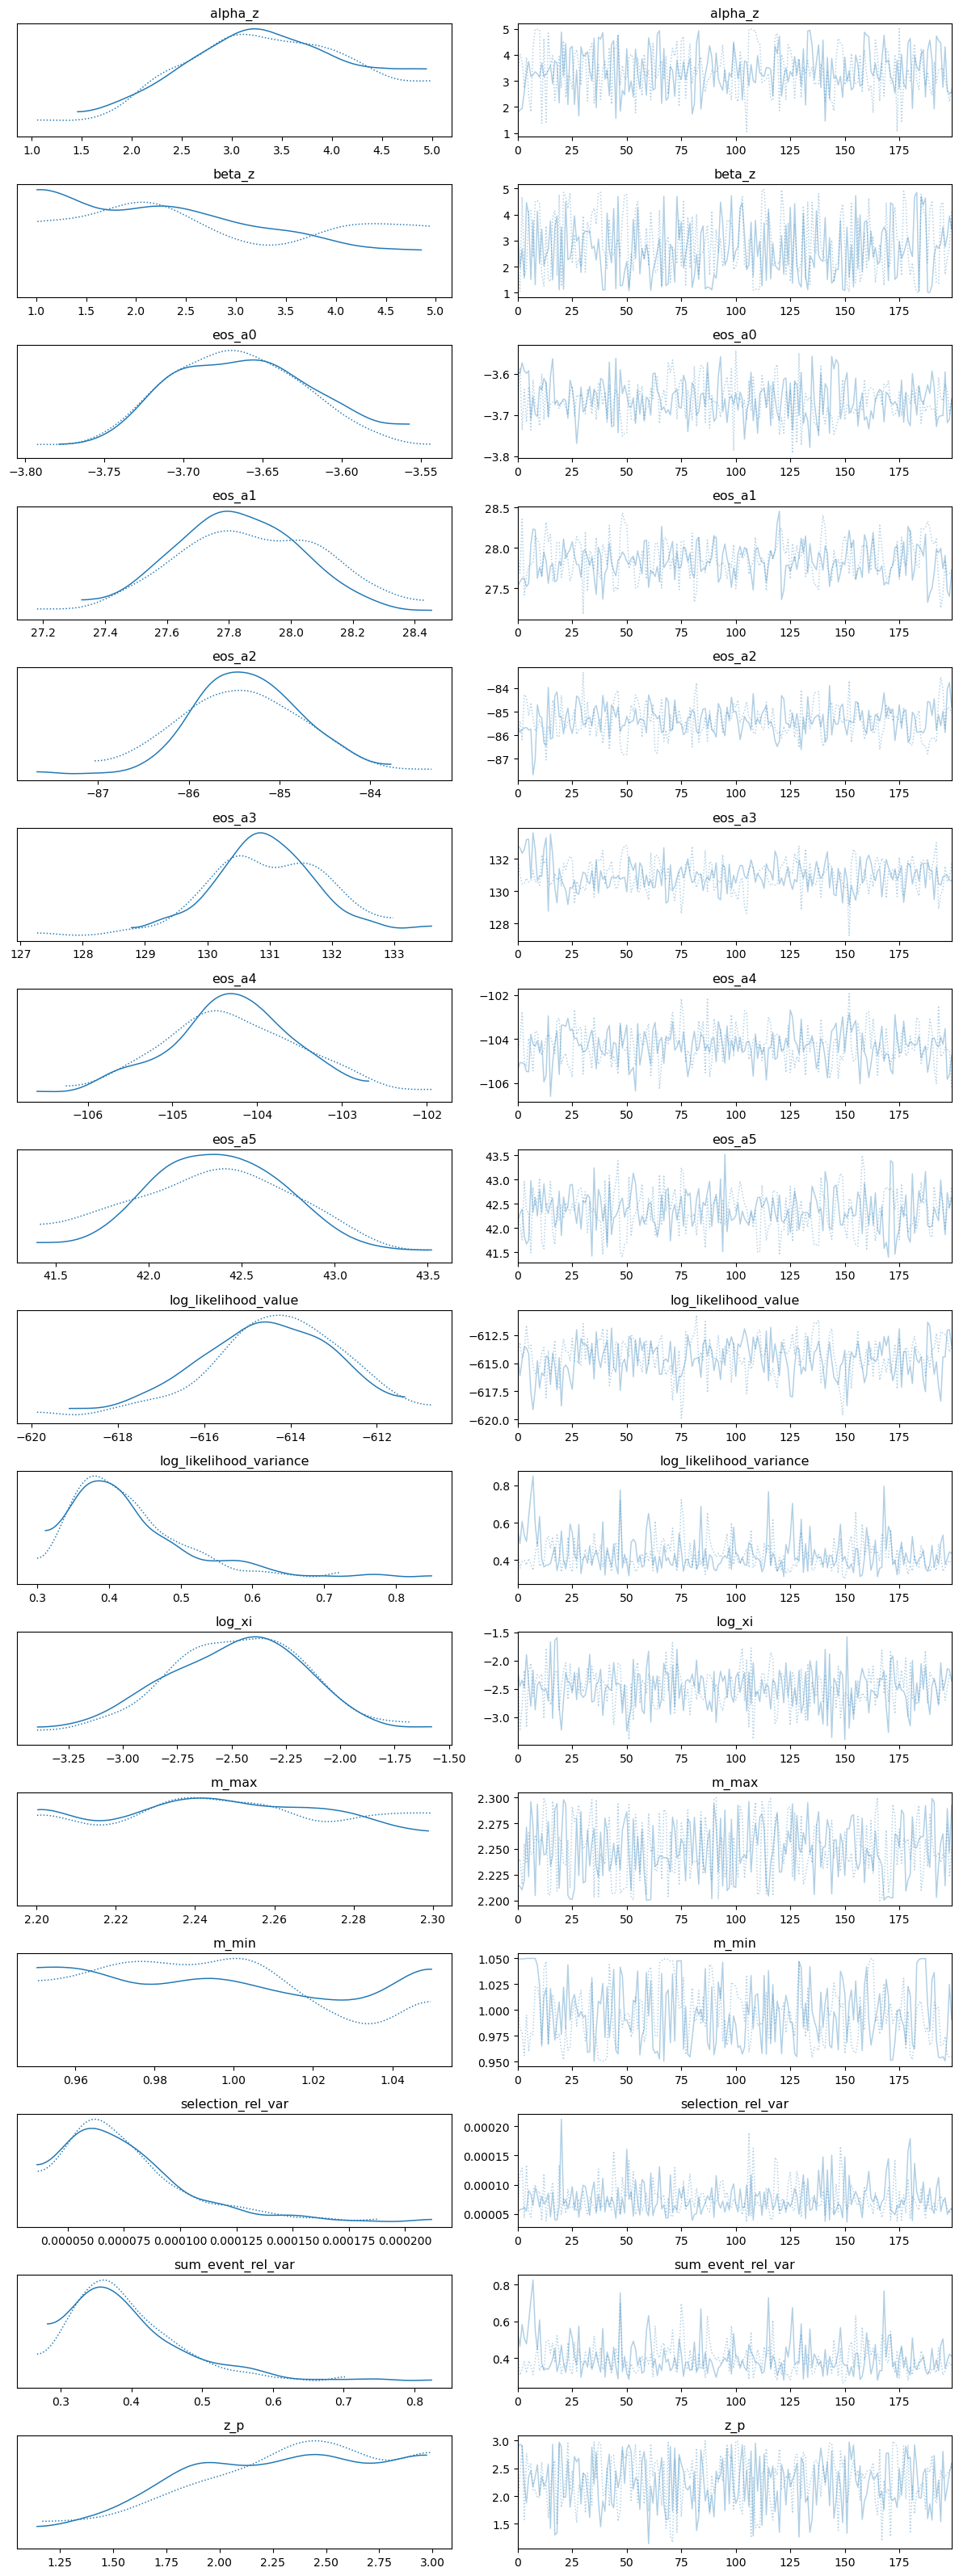

Saved trace plot to /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/figures/trace__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871__inj_n200000_z20_edge0p001_seed1871__inf_nev20_npe500_ninj2000_w200_s200_c2_seed123.png


In [ ]:
trace_var_names = [
    name
    for name in idata.posterior.data_vars
    if idata.posterior[name].dtype.kind not in ["b"]
]

az.plot_trace(
    idata,
    var_names=trace_var_names,
    compact=True,
)

plt.tight_layout()
trace_path = figures_dir / f"trace__{run_tag}.png"
plt.savefig(trace_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved trace plot to {trace_path}")

## Corner plot

The corner plot shows the posterior distribution of the sampled hyperparameters.

The black or red reference lines mark the values used to generate the mock data.

This plot answers questions such as:

- Are the true population parameters recovered?
- Are the EOS coefficients constrained?
- Are there strong degeneracies between population parameters and EOS parameters?
- Are some parameters prior dominated?

The EOS coefficients can be strongly correlated. This is expected because many different polynomial coefficient combinations can produce similar $\Lambda(m)$ curves over the fitted mass range.

For physical interpretation, the EOS posterior check below is often more informative than the coefficient corner plot, because it shows the implied posterior band for $\Lambda_{\rm EOS}(m)$ directly.

In [ ]:
posterior = {
    name: np.asarray(idata.posterior[name].stack(sample=("chain", "draw")).values)
    for name in idata.posterior.data_vars
}

posterior['alpha_z'].shape

(400,)

(400, 11)


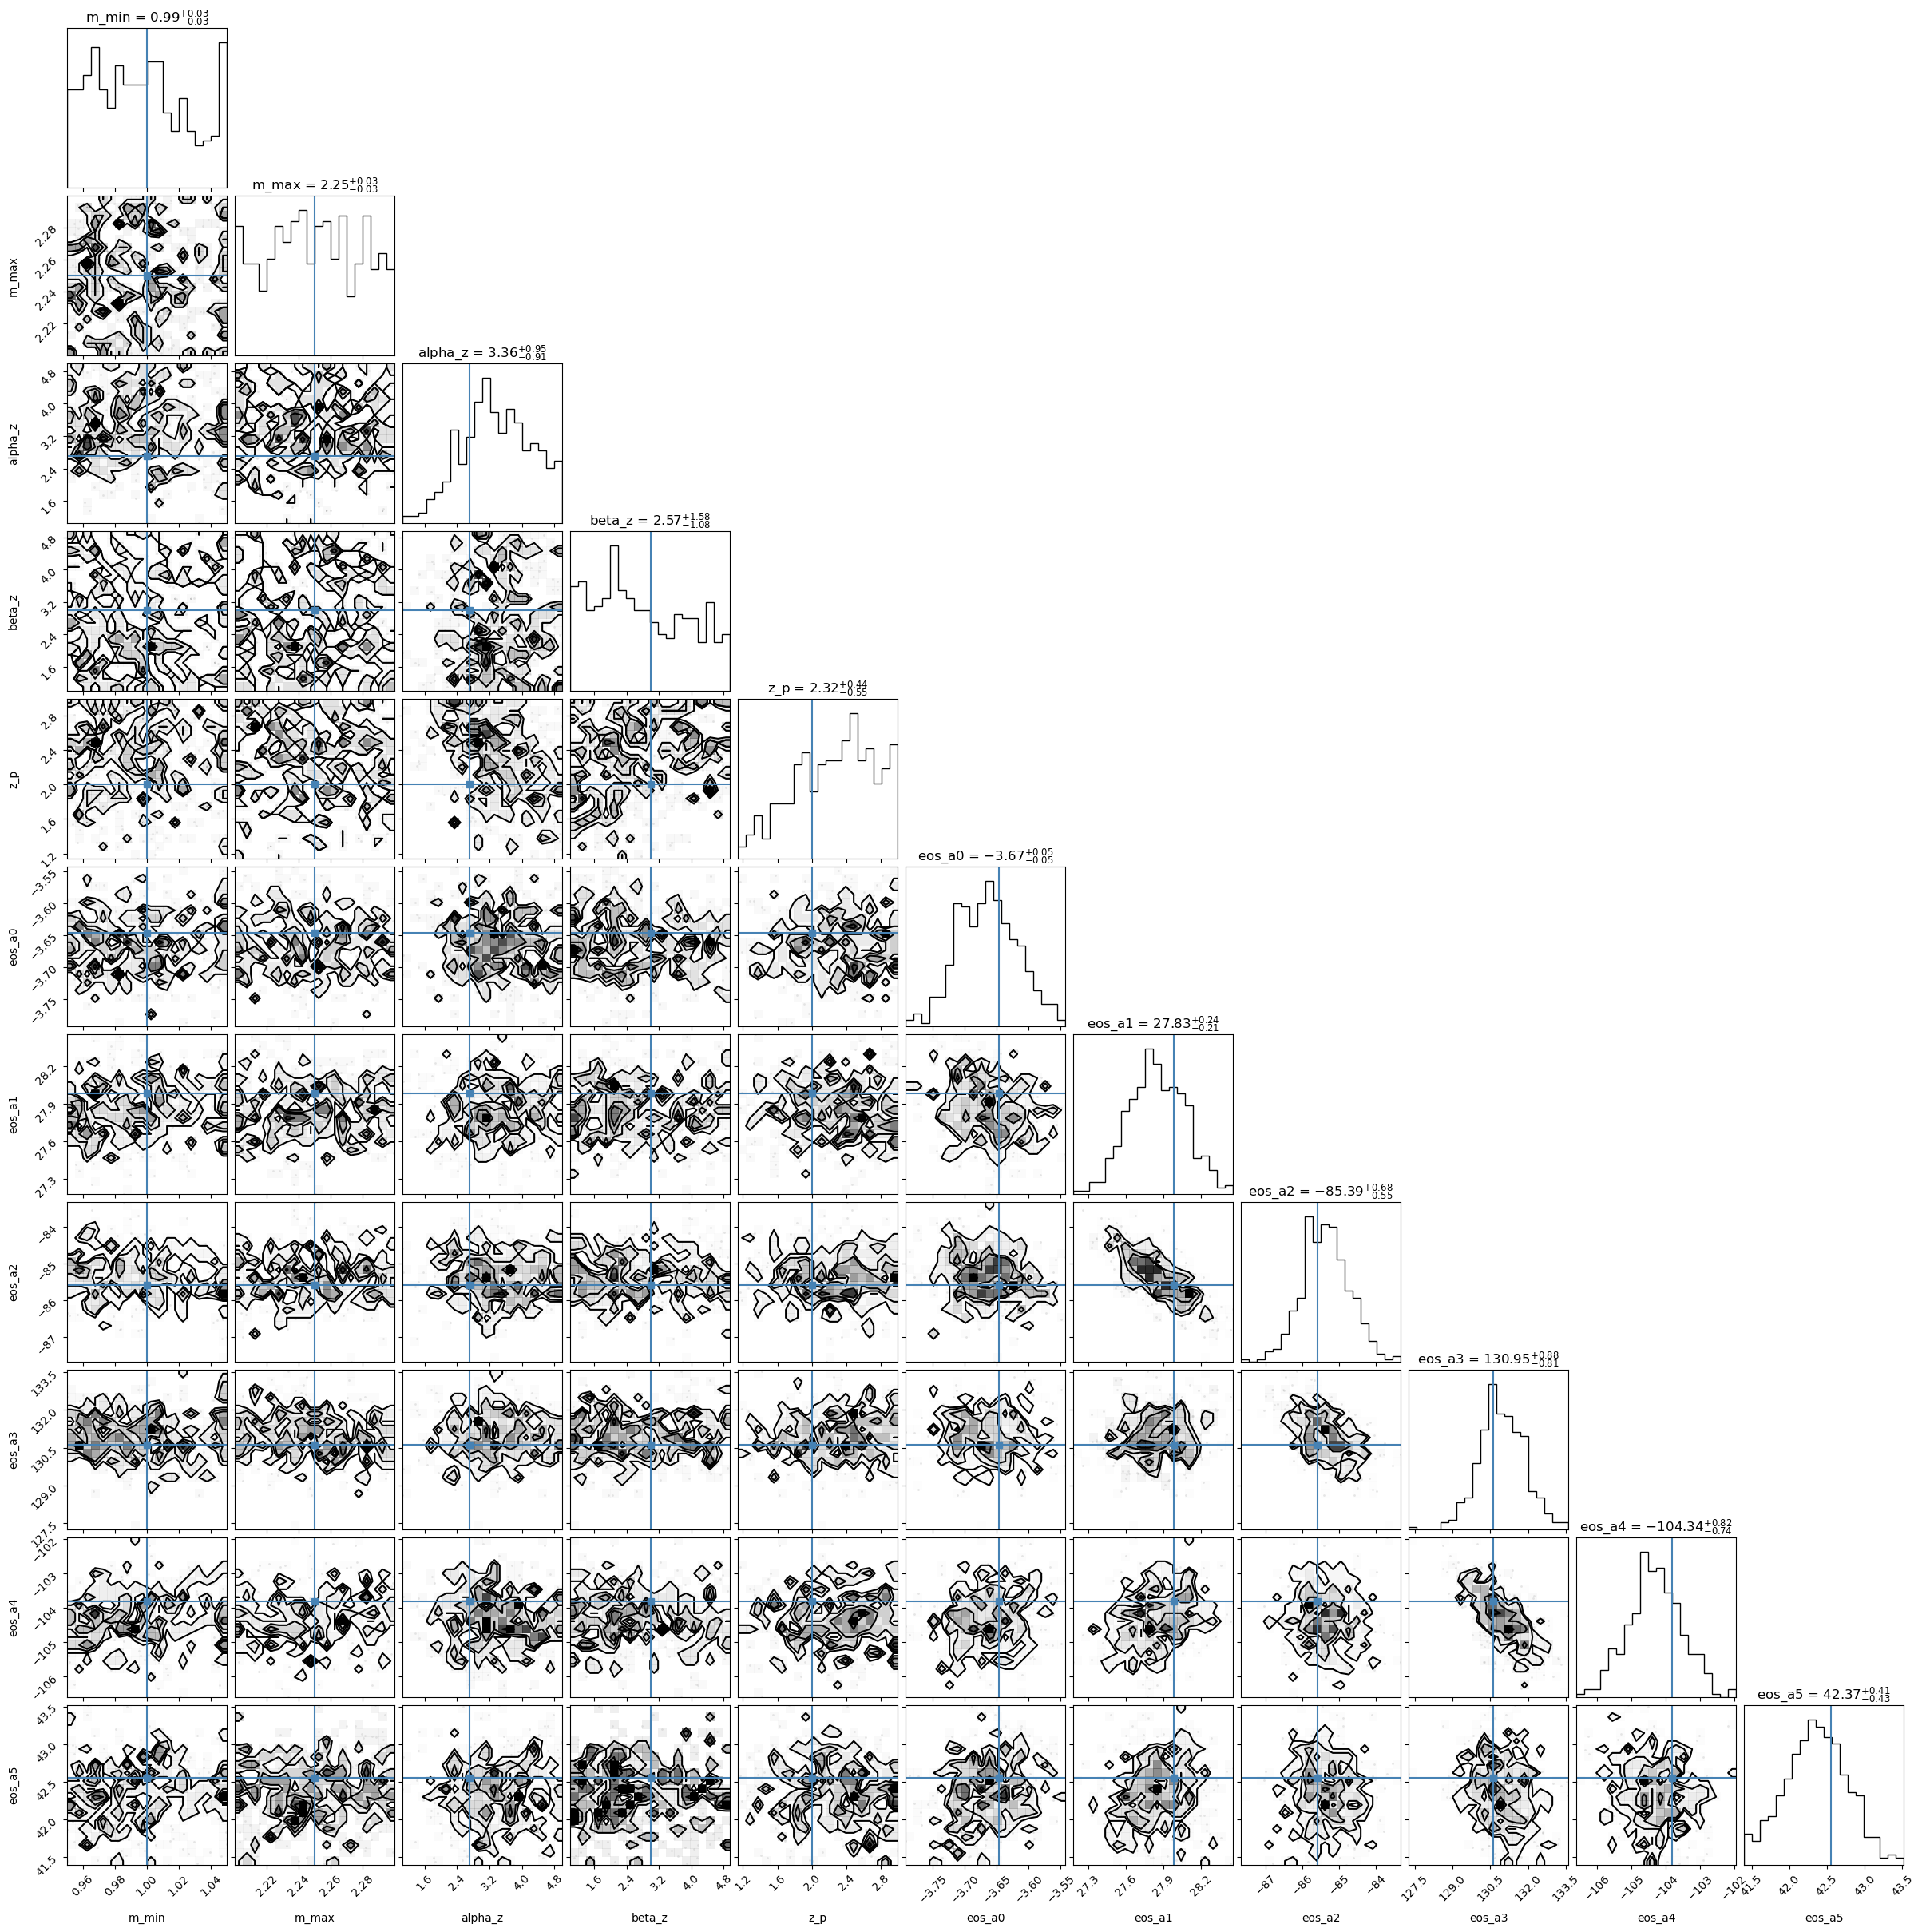

Saved corner plot to /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/figures/corner__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871__inj_n200000_z20_edge0p001_seed1871__inf_nev20_npe500_ninj2000_w200_s200_c2_seed123.png


In [ ]:
#posterior = mcmc.get_samples()

#posterior = idata.posterior

corner_names = [
    name for name, cfg in param_config.items()
    if cfg["sample"] and name in posterior
]

corner_array = np.column_stack([np.asarray(posterior[name]) for name in corner_names])

print(corner_array.shape)

fig = corner.corner(
    corner_array,
    labels=corner_names,
    truths=[param_config[name]["fixed"] for name in corner_names],
    show_titles=True,
)

corner_path = figures_dir / f"corner__{run_tag}.png"
fig.savefig(corner_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved corner plot to {corner_path}")


## Mass-distribution posterior check

The corner plot shows the posterior in parameter space. Here we transform posterior samples into the implied mass distribution.

For each posterior draw, we compute

$$
p(m|\lambda)
$$

over the fitted mass interval.

The plot shows a collection of posterior mass-distribution curves and compares them with the true mass distribution used to generate the mock population.

This is a posterior predictive-style check: it asks whether the inferred hyperparameters reproduce the population-level distribution in a physically meaningful space.

Because the detected catalog is selection biased, the inferred mass distribution should not simply match the histogram of detected masses. The hierarchical likelihood corrects for selection effects through the factor $\xi(\lambda)$.

/var/folders/bz/qc_y_tmj1lv6v__5hy2s54x00000gn/T/ipykernel_44492/3407470705.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pdf_draw /= np.trapz(pdf_draw, m_plot)
/var/folders/bz/qc_y_tmj1lv6v__5hy2s54x00000gn/T/ipykernel_44492/3407470705.py:48: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pdf_true /= np.trapz(pdf_true, m_plot)


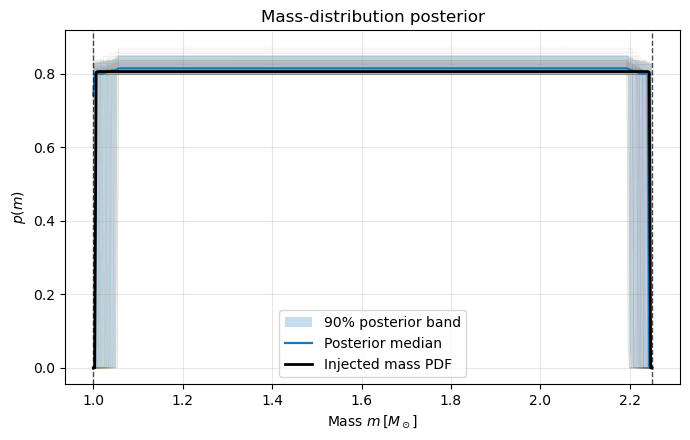

Saved mass posterior plot to /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/figures/mass_posterior__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871__inj_n200000_z20_edge0p001_seed1871__inf_nev20_npe500_ninj2000_w200_s200_c2_seed123.png


In [ ]:
#posterior = mcmc.get_samples()
n_draws_plot = min(200, len(next(iter(posterior.values()))))

draw_ids = rng.choice(len(next(iter(posterior.values()))), size=n_draws_plot, replace=False)
m_plot = np.linspace(fit_min, fit_max, 400)

def bounded_smooth_mass_unnorm_np(m, m_min, m_max, edge_width, edge_pdf_value):
    logit_edge = np.log((1.0 - edge_pdf_value) / edge_pdf_value)
    edge_scale = edge_width / logit_edge

    left = 1.0 / (1.0 + np.exp(-(m - m_min - edge_width) / edge_scale))
    right = 1.0 / (1.0 + np.exp(-(m_max - edge_width - m) / edge_scale))
    return left * right

mass_pdf_draws = []

for draw_id in range(len(next(iter(posterior.values())))):
    if "m_min" in posterior:
        m_min_draw = float(posterior["m_min"][draw_id])
    else:
        m_min_draw = float(param_config["m_min"]["fixed"])

    if "m_max" in posterior:
        m_max_draw = float(posterior["m_max"][draw_id])
    else:
        m_max_draw = float(param_config["m_max"]["fixed"])

    if "edge_width" in posterior:
        edge_width_draw = float(posterior["edge_width"][draw_id])
    else:
        edge_width_draw = float(param_config["edge_width"]["fixed"])

    pdf_draw = bounded_smooth_mass_unnorm_np(
        m_plot, m_min_draw, m_max_draw, edge_width_draw, edge_pdf_value
    )
    pdf_draw /= np.trapz(pdf_draw, m_plot)
    mass_pdf_draws.append(pdf_draw)

mass_pdf_draws = np.array(mass_pdf_draws)

mass_pdf_q05 = np.percentile(mass_pdf_draws, 5, axis=0)
mass_pdf_q50 = np.percentile(mass_pdf_draws, 50, axis=0)
mass_pdf_q95 = np.percentile(mass_pdf_draws, 95, axis=0)

pdf_true = bounded_smooth_mass_unnorm_np(
    m_plot, m_min_true, m_max_true, edge_width_true, edge_pdf_value
)
pdf_true /= np.trapz(pdf_true, m_plot)

fig, ax = plt.subplots(figsize=(7.0, 4.5))

ax.fill_between(
    m_plot,
    mass_pdf_q05,
    mass_pdf_q95,
    alpha=0.25,
    label="90% posterior band",
)

for draw_id in draw_ids:
    ax.plot(m_plot, mass_pdf_draws[draw_id], lw=0.5, alpha=0.06)

ax.plot(m_plot, mass_pdf_q50, lw=1.6, label="Posterior median")
ax.plot(m_plot, pdf_true, color="black", lw=2.0, label="Injected mass PDF")
ax.axvline(m_min_true, color="black", ls="--", lw=1.0, alpha=0.7)
ax.axvline(m_max_true, color="black", ls="--", lw=1.0, alpha=0.7)

ax.set_xlabel(r"Mass $m\,[M_\odot]$")
ax.set_ylabel(r"$p(m)$")
ax.set_title("Mass-distribution posterior")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
mass_path = figures_dir / f"mass_posterior__{run_tag}.png"
fig.savefig(mass_path, dpi=200)
plt.show()

print(f"Saved mass posterior plot to {mass_path}")

## EOS posterior check

The EOS coefficients are difficult to interpret directly. Therefore, we transform each posterior draw of the polynomial coefficients into an EOS curve,

$$
\Lambda_{\rm EOS}(m;\phi_{\rm EOS}).
$$

The plot shows the posterior band for the mass--tidal-deformability relation.

This is the most physically meaningful EOS diagnostic in the notebook.

The injected curve is the polynomial surrogate used to generate the mock data. If the inference is working well and the data are informative enough, the injected curve should lie inside the posterior band.

However, the posterior band may still be wide. This is expected because tidal deformability is weakly measured by individual BNS events, especially when the number of events is small.

This plot illustrates the central idea of the tutorial:

$$
\text{many noisy event-level tidal measurements}
\quad
\Rightarrow
\quad
\text{constraints on one shared EOS curve}.
$$どうなのか…、あでもこれ90パーセント幅か。なるほど井岡さんが5@s欲しがるわけだ。イベント数今は20でこれを桁で増やせばまた変わるらしい

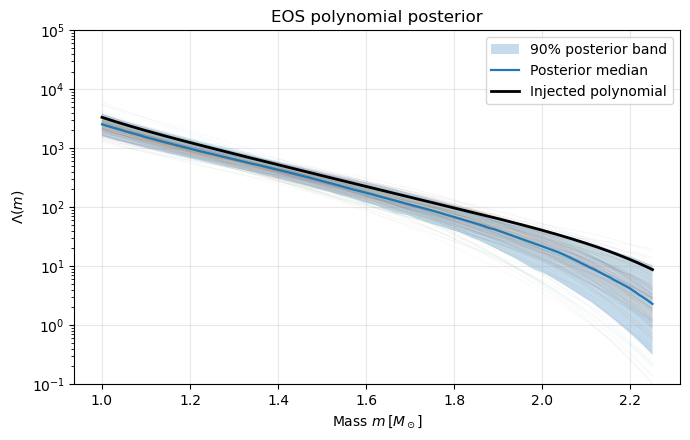

Saved EOS posterior plot to /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/figures/eos_posterior__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871__inj_n200000_z20_edge0p001_seed1871__inf_nev20_npe500_ninj2000_w200_s200_c2_seed123.png


In [ ]:
#posterior = mcmc.get_samples()
n_draws_total = len(posterior["eos_a0"])
n_draws_plot = min(200, n_draws_total)

draw_ids = rng.choice(n_draws_total, size=n_draws_plot, replace=False)
m_plot = np.linspace(fit_min, fit_max, 300)

fit_lambda = np.exp(np.polyval(eos_coeffs_fit, m_plot))

lambda_draws = []

for draw_id in range(n_draws_total):
    coeff_draw = np.array([
        posterior[f"eos_a{k}"][draw_id]
        for k in range(eos_order + 1)
    ])
    lambda_draw = np.exp(np.polyval(coeff_draw, m_plot))
    lambda_draws.append(lambda_draw)

lambda_draws = np.array(lambda_draws)

lambda_q05 = np.percentile(lambda_draws, 5, axis=0)
lambda_q50 = np.percentile(lambda_draws, 50, axis=0)
lambda_q95 = np.percentile(lambda_draws, 95, axis=0)

fig, ax = plt.subplots(figsize=(7.0, 4.5))

ax.fill_between(
    m_plot,
    lambda_q05,
    lambda_q95,
    alpha=0.25,
    label="90% posterior band",
)

for draw_id in draw_ids:
    ax.plot(m_plot, lambda_draws[draw_id], lw=0.5, alpha=0.06)

ax.plot(m_plot, lambda_q50, lw=1.6, label="Posterior median")
ax.plot(m_plot, fit_lambda, color="black", lw=2.0, label="Injected polynomial")

ax.set_yscale("log")
ax.set_ylim(0.1, 1e05)
ax.set_xlabel(r"Mass $m\,[M_\odot]$")
ax.set_ylabel(r"$\Lambda(m)$")
ax.set_title("EOS polynomial posterior")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
eos_path = figures_dir / f"eos_posterior__{run_tag}.png"
fig.savefig(eos_path, dpi=200)
plt.show()

print(f"Saved EOS posterior plot to {eos_path}")

## Monte Carlo variance diagnostics

The hierarchical likelihood is estimated with two Monte Carlo sums:

1. a sum over PE samples for each event;
2. a sum over detected injections for the selection correction.

These estimates are noisy if too few samples support a proposed hyperparameter value.

The plotted quantity

$$
\sigma^2_{\log\widehat{\mathcal{L}}}
$$

estimates the variance of the log likelihood due to Monte Carlo error.

The usual GW population-inference requirement is approximately

$$
\sigma^2_{\log\widehat{\mathcal{L}}}<1.
$$

The diagnostic is decomposed into:

- the PE-sample contribution from the detected events;
- the injection contribution from the selection correction.

If the event contribution is large, more PE samples per event are needed, or the population model is placing weight in regions poorly covered by the PE posterior samples.

If the selection contribution is large, more detected injections are needed, or the injection draw distribution does not cover the important region efficiently.

These diagnostics are essential because a noisy likelihood can produce biased or unstable posterior samples.

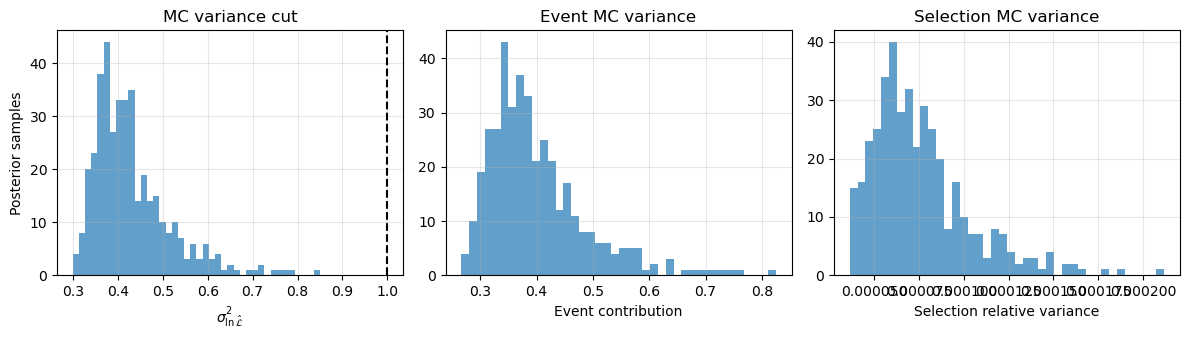

Saved MC variance plot to /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/figures/mc_variance__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871__inj_n200000_z20_edge0p001_seed1871__inf_nev20_npe500_ninj2000_w200_s200_c2_seed123.png


In [ ]:
#posterior = mcmc.get_samples()

fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.5))

axes[0].hist(np.asarray(posterior["log_likelihood_variance"]), bins=40, alpha=0.7)
axes[0].axvline(max_log_likelihood_variance, color="black", ls="--")
axes[0].set_xlabel(r"$\sigma^2_{\ln\hat{\mathcal{L}}}$")
axes[0].set_ylabel("Posterior samples")
axes[0].set_title("MC variance cut")

axes[1].hist(np.asarray(posterior["sum_event_rel_var"]), bins=40, alpha=0.7)
axes[1].set_xlabel("Event contribution")
axes[1].set_title("Event MC variance")

axes[2].hist(np.asarray(posterior["selection_rel_var"]), bins=40, alpha=0.7)
axes[2].set_xlabel("Selection relative variance")
axes[2].set_title("Selection MC variance")

for ax in axes:
    ax.grid(alpha=0.3)

fig.tight_layout()
mcvar_path = figures_dir / f"mc_variance__{run_tag}.png"
fig.savefig(mcvar_path, dpi=200)
plt.show()

print(f"Saved MC variance plot to {mcvar_path}")


## Relation to real EOS analyses

The simplified treatment in this tutorial is closely related to what is done in more realistic EOS analyses, but with an important simplification.

Here, the mock PE likelihood was designed so that the tidal part can be written as a simple Gaussian in

$$
\log\tilde{\Lambda}.
$$

That is why we can analytically collapse the tidal integral and evaluate

$$
p(d_i^{\rm tidal}|x,\phi_{\rm EOS})
=
\mathcal{N}
\left[
\widehat{\log\tilde{\Lambda}}_i
\middle|
\log\tilde{\Lambda}_{\rm EOS}(x;\phi_{\rm EOS}),
\sigma_{\log\tilde{\Lambda},i}
\right].
$$

In real gravitational-wave PE, the likelihood is not usually available in such a simple separable form. Instead, the likelihood is a correlated function of masses, spins, distance, inclination, and tidal parameters.

A common strategy is therefore to construct an approximate representation of the GW likelihood from posterior samples. For example, one can fit a density estimator in the relevant variables,

$$
(m_1,m_2,\Lambda_1,\Lambda_2),
$$

or in a detector-frame equivalent, and then evaluate this approximate likelihood along the EOS-predicted surface

$$
\Lambda_1=\Lambda_{\rm EOS}(m_1;\phi_{\rm EOS}),
\qquad
\Lambda_2=\Lambda_{\rm EOS}(m_2;\phi_{\rm EOS}).
$$

Schematically, for a proposed EOS realization $\phi_{\rm EOS}$,

$$
p(d_i|\phi_{\rm EOS})
=
\int dm_1\,dm_2\,
p(m_1,m_2)
\,
\mathcal{L}_i
\left[
m_1,m_2,
\Lambda_{\rm EOS}(m_1;\phi_{\rm EOS}),
\Lambda_{\rm EOS}(m_2;\phi_{\rm EOS})
\right].
$$

This is the same conceptual operation as in this tutorial: evaluate the event likelihood on the EOS-implied tidal relation. The difference is that a real analysis needs an approximate multidimensional likelihood representation, rather than the simple one-dimensional Gaussian tidal factor used here.

This is done, for example, in nonparametric EOS analyses of GW170817 (https://arxiv.org/pdf/1910.09740), where Gaussian kernel-density estimates are used to represent the GW likelihood in the space

$$
(M_1,M_2,\Lambda_1,\Lambda_2),
$$

and the likelihood is evaluated at

$$
\Lambda_1=\Lambda_{\rm EOS}(M_1),
\qquad
\Lambda_2=\Lambda_{\rm EOS}(M_2).
$$

Recent projected A+/O5 studies (https://arxiv.org/pdf/2501.11585) use the same broad idea in a more realistic pipeline: they simulate BNS signals, run full PE, interpolate the PE information with KDEs, and then infer EOS information using flexible EOS models such as Gaussian processes.

Therefore, the tutorial should be read as a transparent toy version of the same statistical structure:

$$
\text{event likelihood}
+
\text{EOS relation}
+
\text{selection correction}
\quad
\Rightarrow
\quad
\text{hierarchical EOS inference}.
$$

### Alternative: sampling the full hierarchical posterior

The approach used in this notebook follows the common population-inference strategy: for each proposed set of hyperparameters, we marginalize over event-level parameters using PE samples,

$$
\widehat{p}(d_i|\lambda)
=
\frac{1}{N_{\rm PE}}
\sum_{j=1}^{N_{\rm PE}}
\frac{
p_{\rm pop}(\theta_{ij}|\lambda)
}{
\pi_{\rm PE}(\theta_{ij})
}.
$$

This reduces the dimensionality of the sampling problem, because the sampler only explores the hyperparameters $\lambda$. The price is that the likelihood contains Monte Carlo sums over PE samples and injections, and these sums have finite-sample variance.

An alternative strategy is to sample the full hierarchical posterior, including both the population hyperparameters and the event-level parameters: https://arxiv.org/abs/2502.12156.

In this case,

$$
p(\lambda,\{\theta_i\}|\{d_i\})
\propto
\pi(\lambda)
\prod_i
p(d_i|\theta_i)
p_{\rm pop}(\theta_i|\lambda)
\times
\text{selection correction}.
$$

In this formulation, the event-level parameters $\theta_i$ are sampled together with the population parameters $\lambda$. This gives direct access to population-informed event parameters and to correlations between individual events and the population model.

The drawback is dimensionality: if there are many events and each event has several parameters, the posterior can have hundreds of dimensions. Modern probabilistic programming and gradient-based samplers such as HMC/NUTS can make this feasible.

This is the idea explored by Mancarella & Gerosa (2025) https://arxiv.org/abs/2502.12156, who sample the full hierarchical population posterior for GWTC-3 black holes. Their analysis uses continuous interpolations of the single-event posterior probabilities.

### Alternative: relax the delta function prior


Another possible mitigation strategy is to relax the deterministic EOS constraint itself. Instead of imposing an exact delta function,

$$
p(\tilde{\Lambda}|m_1,m_2,\phi_{\rm EOS})
=
\delta\left[
\tilde{\Lambda}
-
\tilde{\Lambda}_{\rm EOS}(m_1,m_2;\phi_{\rm EOS})
\right],
$$

one can replace it by a narrow but finite-width distribution, for example

$$
p(\log\tilde{\Lambda}|m_1,m_2,\phi_{\rm EOS},\sigma_{\rm EOS})
=
\mathcal{N}
\left[
\log\tilde{\Lambda}
\middle|
\log\tilde{\Lambda}_{\rm EOS}(m_1,m_2;\phi_{\rm EOS}),
\sigma_{\rm EOS}
\right].
$$

This turns the exact EOS surface into a soft constraint. Numerically, this can reduce Monte Carlo instability because PE samples do not have to lie exactly on a lower-dimensional EOS manifold.

This should be interpreted carefully. If the EOS is universal, the physical EOS relation should not fluctuate independently from event to event. Therefore, this softening is best understood as a numerical or phenomenological regularization, not automatically as a fundamental model of EOS uncertainty.

Notebook 05 explores this idea in more detail. It compares the strict delta-function treatment to a softened EOS constraint and studies how the finite-width constraint affects Monte Carlo stability.